In [ ]:
from dinov2.data.datasets.s2_csv import S2CsvDataset
from torchvision import transforms
from torch.utils.data import DataLoader

# 先算一次均值方差（可选）
# from dinov2.utils.data import compute_dataset_stats
# tmp_ds = S2CsvDataset(csv_path="data_csv/96_3_train.csv", scale_to_unit=True, pad_to_multiple=14, normalize_stats=None)
# compute_dataset_stats(tmp_ds, subset=0.1)  # 输出 mean/std，填到 normalize_stats

train_tf = transforms.Compose([
    # 这里可以插入你需要的随机裁剪/翻转
])

ds_train = S2CsvDataset(
    csv_path="data_csv/96_3_train.csv",
    ds_cfg_name="s2_12band",
    normalize_stats=None,   # 如果已有 mean/std，填为 (mean, std)
    scale_to_unit=True,     # uint16 -> [0,1]
    pad_to_multiple=14,     # 96 -> 98，避免 patch 截断
    transform=train_tf,
)

ds_test = S2CsvDataset(
    csv_path="data_csv/96_3_test.csv",
    ds_cfg_name="s2_12band",
    normalize_stats=None,
    scale_to_unit=True,
    pad_to_multiple=14,
    transform=None,
)

train_loader = DataLoader(ds_train, batch_size=64, shuffle=True, num_workers=8)
test_loader = DataLoader(ds_test, batch_size=64, shuffle=False, num_workers=8)


In [9]:
from dinov2.data.datasets.s2_csv import S2CsvDataset

csv = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s2_90360_temporal_CDSE0_gee90360_2024_16/train.csv"
subset = 1000  # 2% 抽样，可改为 int 比如 500
ds = S2CsvDataset(
    csv_path=csv,
    ds_cfg_name="s2_12band",
    scale_to_unit=False,
    compute_stats=True,
    compute_stats_subset=subset,
    pad_to_multiple=None,  # 统计时不需要 padding
)

mean, std = ds.get_normalize_stats()
print("mean =", mean.tolist())
print("std  =", std.tolist())

csv = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s2_90360_temporal_CDSE0_gee90360_2024_16/test.csv"
subset = 1000  # 2% 抽样，可改为 int 比如 500
ds = S2CsvDataset(
    csv_path=csv,
    ds_cfg_name="s2_12band",
    scale_to_unit=False,
    compute_stats=True,
    compute_stats_subset=subset,
    pad_to_multiple=None,  # 统计时不需要 padding
)

mean, std = ds.get_normalize_stats()
print("mean =", mean.tolist())
print("std  =", std.tolist())


mean = [1834.1697998046875, 1997.9698486328125, 2386.554443359375, 2793.37060546875, 3182.25830078125, 3513.309814453125, 3685.052001953125, 3930.157958984375, 0.0, 0.0, 4635.279296875, 3836.010009765625]
std  = [328.0159912109375, 454.60638427734375, 554.505615234375, 723.8554077148438, 740.930419921875, 683.3168334960938, 673.1165771484375, 652.6875, 9.999999974752427e-07, 9.999999974752427e-07, 679.613525390625, 731.38232421875]
mean = [2201.8984375, 2484.21337890625, 2947.541748046875, 3823.814208984375, 4148.443359375, 4329.40576171875, 4488.68310546875, 4666.5751953125, 0.0, 0.0, 5810.994140625, 5510.0078125]
std  = [484.7310485839844, 645.2403564453125, 760.5748901367188, 910.9255981445312, 951.3125, 925.4602661132812, 925.116943359375, 906.8043212890625, 9.999999974752427e-07, 9.999999974752427e-07, 681.802978515625, 640.1221923828125]


In [10]:
import pandas as pd
import tempfile
from pathlib import Path

from dinov2.data.datasets.s2_csv import S2CsvDataset

# ======================
# Config
# ======================
TRAIN_CSV = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s2_90360_temporal_CDSE0_gee90360_2024_16/train.csv"
TEST_CSV  = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s2_90360_temporal_CDSE0_gee90360_2024_16/test.csv"

N_TRAIN = 1000
N_TEST  = 1000
RANDOM_SEED = 42

# ======================
# 1) Load & sample
# ======================
df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)

df_train_sub = df_train.sample(n=N_TRAIN, random_state=RANDOM_SEED)
df_test_sub  = df_test.sample(n=N_TEST,  random_state=RANDOM_SEED)

df_mix = pd.concat([df_train_sub, df_test_sub], ignore_index=True)

print(f"[INFO] Mixed samples: train={len(df_train_sub)}, test={len(df_test_sub)}, total={len(df_mix)}")

# ======================
# 2) Write temp CSV
# ======================
tmp_dir = Path(tempfile.mkdtemp())
MIXED_CSV = tmp_dir / "train_test_mixed_2000.csv"
df_mix.to_csv(MIXED_CSV, index=False)

print(f"[INFO] Mixed CSV saved to: {MIXED_CSV}")

# ======================
# 3) Compute stats
# ======================
ds = S2CsvDataset(
    csv_path=str(MIXED_CSV),
    ds_cfg_name="s2_12band",
    scale_to_unit=False,
    compute_stats=True,
    compute_stats_subset=None,  # 已经是 2000，全用
    pad_to_multiple=None,
)

mean, std = ds.get_normalize_stats()

print("mean =", mean.tolist())
print("std  =", std.tolist())


[INFO] Mixed samples: train=1000, test=1000, total=2000
[INFO] Mixed CSV saved to: /tmp/tmphmho_tkd/train_test_mixed_2000.csv
mean = [2023.93408203125, 2267.178466796875, 2703.1396484375, 3257.457275390625, 3589.15478515625, 3874.7529296875, 4058.203125, 4229.97802734375, 0.0, 0.0, 4915.81591796875, 4429.00439453125]
std  = [659.8005981445312, 759.5709838867188, 878.8653564453125, 1164.0340576171875, 1186.4278564453125, 1077.7305908203125, 1084.9752197265625, 1064.8203125, 9.999999974752427e-07, 9.999999974752427e-07, 1363.797119140625, 1409.4805908203125]


In [6]:
import os
import pandas as pd
import tifffile
from collections import Counter

csv = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_s2_-790360_32_2024/train_patches.csv"
df = pd.read_csv(csv)

cnt = Counter()
bad = []
for p in df["s2_pre_pre_path"].dropna().astype(str):
    if not os.path.exists(p):
        cnt["missing"] += 1
        continue
    try:
        arr = tifffile.imread(p)
        cnt[str(arr.shape)] += 1
        # 记录一下异常的
        if not (arr.ndim == 3 and arr.shape[0] == 12 and arr.shape[1] == 32 and arr.shape[2] == 32):
            bad.append((p, arr.shape))
    except Exception as e:
        cnt["read_fail"] += 1
        bad.append((p, f"FAIL:{e}"))

print("Shape counts:")
for k,v in cnt.most_common():
    print(v, k)

print("\nFirst 20 abnormal samples:")
for item in bad[:20]:
    print(item)


Shape counts:
4288 (12, 32, 32)

First 20 abnormal samples:


In [ ]:
import numpy as np
import tifffile

def plume_ratio(mask_path):
    m = tifffile.imread(mask_path)
    return (m > 0).mean()

# 分别算 train/test 的 label=1
mask_path="/home/yuyao/panopticon/data_csv/96_3_train.csv"
print(plume_ratio(mask_path))

In [6]:
import pandas as pd
from pathlib import Path

csv_path = Path("data_csv/hongxuan_temporal_32/test.csv")

df = pd.read_csv(csv_path)
df.to_csv(csv_path.with_suffix(".bak"), index=False)

df["plume_mask_path"] = df["plume_mask_path"].str.replace(
    r"^/home", "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao", regex=True
)

df.to_csv(csv_path, index=False)

In [1]:
from dinov2.data.datasets.landsat_csv import Landsat89CsvDataset

train_csv = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/emit_60m_to_224_classification_2025/train_permian.csv"
ds = Landsat89CsvDataset(
    csv_path=train_csv,
    ds_cfg_name="landsat89_7band",
    scale_to_unit=False,        # 若已是反射率则设 False
    compute_stats=True,
    compute_stats_subset=1000,  # 可选，加速
    pad_to_multiple=None,
    drop_extra_bands=True,     # 只保留 SR_B1..SR_B7
)
mean, std = ds.get_normalize_stats()
print("mean =", [float(m) for m in mean])
print("std  =", [float(s) for s in std])

mean = [0.12139824777841568, 0.14210745692253113, 0.1989395022392273, 0.2627725303173065, 0.356589138507843, 0.47721537947654724, 0.40299171209335327]
std  = [0.017132749781012535, 0.020369281992316246, 0.02752421796321869, 0.03416186571121216, 0.036992188543081284, 0.03588271513581276, 0.034712810069322586]


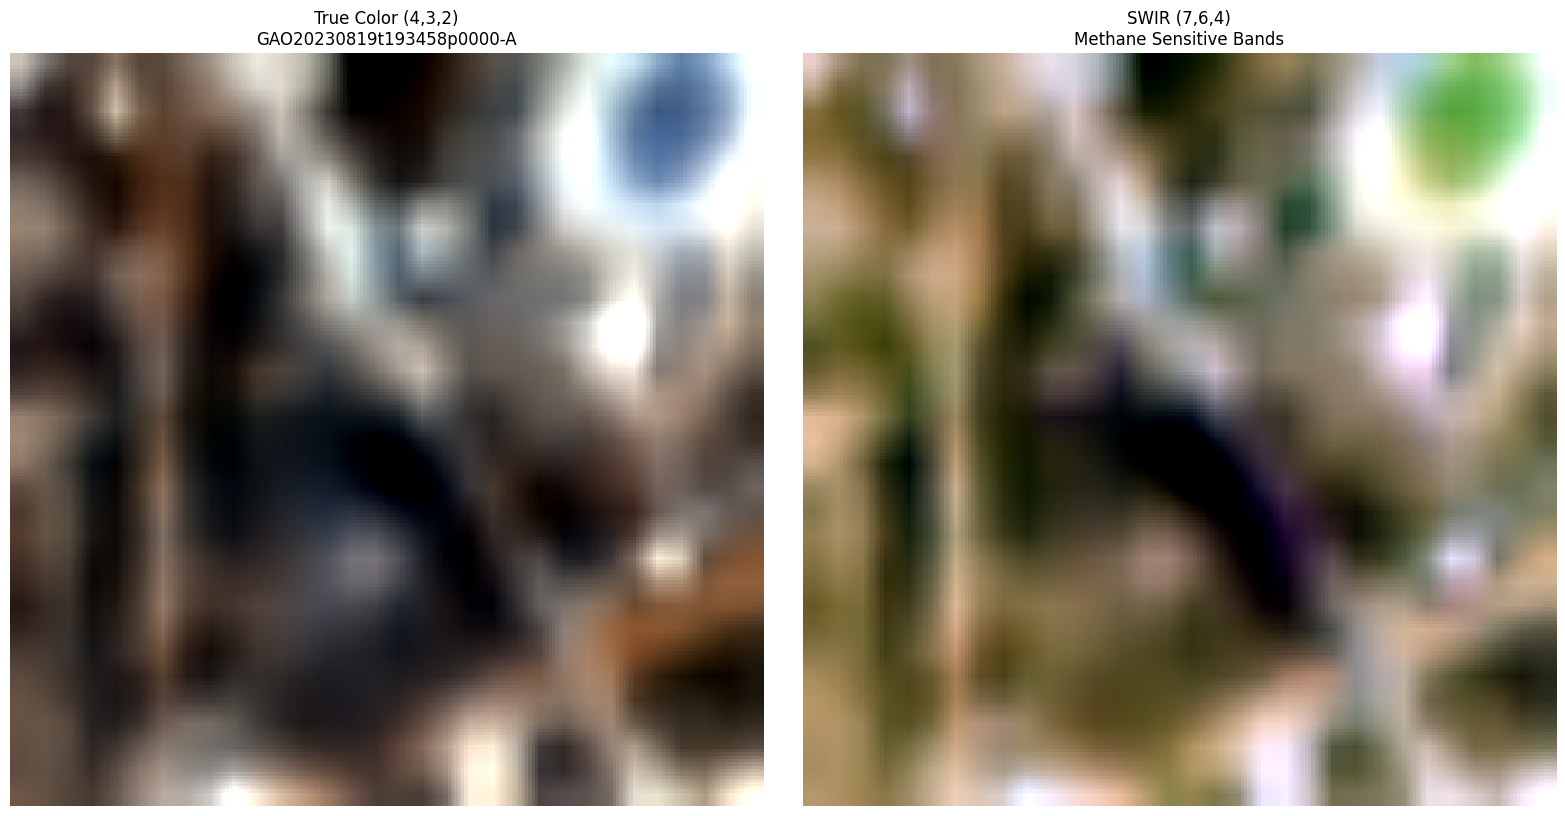

In [4]:
import pandas as pd
import numpy as np
import tifffile
import matplotlib.pyplot as plt
import os

def normalize(band, p_low=2, p_high=98):
    """Percentile scaling for display."""
    valid_mask = (band > 0) & (~np.isnan(band))
    if not np.any(valid_mask):
        return np.zeros_like(band)
    
    # Clip and scale
    low, high = np.nanpercentile(band[valid_mask], p_low), np.nanpercentile(band[valid_mask], p_high)
    band_clipped = np.clip(band, low, high)
    return (band_clipped - low) / (high - low)

def visualize_with_tifffile(csv_path, row_index=0):
    df = pd.read_csv(csv_path)
    df=df.head(10)
    img_path = df.iloc[row_index]['path_t0']
    plume_id = df.iloc[row_index].get('plume_id', 'Unknown')

    if not os.path.exists(img_path):
        print(f"File path invalid: {img_path}")
        return

    # Load using tifffile
    # data shape will be (7, 512, 512) for L89
    data = tifffile.imread(img_path).astype(np.float32)

    # L89 Band Indexing (0-based in tifffile):
    # 0:Coastal, 1:Blue, 2:Green, 3:Red, 4:NIR, 5:SWIR1, 6:SWIR2
    
    # 1. True Color (Bands 4, 3, 2)
    r = normalize(data[3])
    g = normalize(data[2])
    b = normalize(data[1])
    rgb_img = np.dstack((r, g, b))

    # 2. SWIR (Bands 7, 6, 4) 
    # Methane signal is strongest in SWIR bands (5 and 6)
    s2 = normalize(data[6])
    s1 = normalize(data[5])
    swir_img = np.dstack((s2, s1, r))

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    axes[0].imshow(rgb_img)
    axes[0].set_title(f"True Color (4,3,2)\n{plume_id}")
    axes[0].axis('off')

    axes[1].imshow(swir_img)
    axes[1].set_title(f"SWIR (7,6,4)\nMethane Sensitive Bands")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualization
CSV_FILE = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/emit_60m_to_224_classification_2025/train_permian.csv"
visualize_with_tifffile(CSV_FILE, row_index=0)

In [4]:
import numpy as np
import pandas as pd
from pathlib import Path

CSV_PATH = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s5p_patches_3x3_to_32_offl/train_samples.csv"
NPZ_KEY = None          # 如果 NPZ 里有特定 key，填字符串；否则用第一个数组
ALLOW_PICKLE = True     # 如果保存方式需要 pickle，设为 True
NAN_TO_NUM = 0.0        # 将 NaN/Inf 替换成该值；如不需要可设为 None

df = pd.read_csv(CSV_PATH)
paths = df["image_path"].tolist()

sum_c = None
sumsq_c = None
count = 0

for i, p in enumerate(paths, 1):
    with np.load(p, allow_pickle=ALLOW_PICKLE) as npz:
        arr = np.array(npz[NPZ_KEY]) if NPZ_KEY is not None else np.array(npz[npz.files[0]])
    # 确保形状为 (C,H,W)
    if arr.ndim == 2:
        arr = arr[None, ...]
    elif arr.ndim == 3 and arr.shape[0] not in (1, 3):
        arr = np.transpose(arr, (2, 0, 1))
    if NAN_TO_NUM is not None:
        arr = np.nan_to_num(arr, nan=NAN_TO_NUM, posinf=NAN_TO_NUM, neginf=NAN_TO_NUM)

    if sum_c is None:
        c = arr.shape[0]
        sum_c = np.zeros(c, dtype=np.float64)
        sumsq_c = np.zeros(c, dtype=np.float64)
    count += arr.shape[1] * arr.shape[2]
    sum_c += arr.sum(axis=(1, 2))
    sumsq_c += (arr * arr).sum(axis=(1, 2))

    if i % 500 == 0:
        print(f"Processed {i}/{len(paths)} files...")

mean = sum_c / count
std = np.sqrt((sumsq_c / count) - mean**2)

print("mean:", mean.tolist())
print("std:", std.tolist())

Processed 500/6222 files...
Processed 1000/6222 files...
Processed 1500/6222 files...
Processed 2000/6222 files...
Processed 2500/6222 files...
Processed 3000/6222 files...
Processed 3500/6222 files...
Processed 4000/6222 files...
Processed 4500/6222 files...
Processed 5000/6222 files...
Processed 5500/6222 files...
Processed 6000/6222 files...
mean: [1908.944798144908, 362.20128748570943, 666.5645739544017]
std: [52.2615669211965, 743.7553740768346, 901.8399543163595]


In [ ]:
# 把 csv 路径和列名改成你自己的
csv='/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224/train.csv'
cols="path_t0 path_t90 path_t360"

import pandas as pd, tifffile as tiff
from collections import Counter
cols = cols.split()
df = pd.read_csv(csv)
hist = Counter()

for i, row in df.head(5).iterrows():  # 先检查前 5 条，可改大
    print(f"--- sample {i} ---")
    for c in cols:
        path = row[c]
        arr = tiff.imread(path)
        hist[arr.shape[0]] += 1
        print(f"{c}: shape={arr.shape}, dtype={arr.dtype}, path={path}")
print("channel count histogram:", hist)



--- sample 0 ---


KeyError: 'p'

In [ ]:
import os
import sys
import pandas as pd
import tifffile as tiff
from concurrent.futures import ThreadPoolExecutor, as_completed

# --- CONFIGURATION ---
# Since sys.argv[1] fails in Jupyter, set your path here:
csv_path = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224_updated/train.csv'
cols = ["path_t0", "path_t90", "path_t360"]
max_workers = 28  # Increased for potentially high-latency mount
# ---------------------

def validate_row(row_data):
    idx, row = row_data
    for col in cols:
        p = row[col]
        if not os.path.isfile(p):
            return (idx, col, "missing file")
        try:
            # Fast check: only read the header/tags, not the pixels
            with tiff.TiffFile(p) as tf:
                _ = tf.pages[0].shape 
        except Exception as e:
            return (idx, col, str(e))
    return None

df = pd.read_csv(csv_path)
bad = []

print(f"Checking {len(df)} rows with {max_workers} threads...")

# Using a list of tuples for lighter memory usage in threads
tasks = list(df.iterrows())

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    # Map the tasks to the function
    futures = {executor.submit(validate_row, task): task for task in tasks}
    
    for i, future in enumerate(as_completed(futures)):
        res = future.result()
        if res:
            bad.append(res)
        
        if i % 2000 == 0:
            print(f"Validated {i}/{len(df)} rows...")

print(f"\n✅ Done. Checked {len(df)} rows; Found {len(bad)} issues.")

if bad:
    print("\nFirst 20 errors:")
    for r, c, msg in bad[:20]:
        print(f"Row {r} | Col {c}: {msg}")

Checking 37986 rows with 28 threads...
Validated 0/37986 rows...
Validated 2000/37986 rows...
Validated 4000/37986 rows...
Validated 6000/37986 rows...


In [4]:
#!/usr/bin/env python
import numpy as np
import pandas as pd
import tifffile as tiff
from tqdm import tqdm

csv_path = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/emit_60m_to_224_classification_2025/train_permian.csv"
# time_cols = ["path_t0", "path_t90", "path_t360"]
time_cols = ["path_t0"]
max_band = 7  
df = pd.read_csv(csv_path)
df = df.head(1000)

def read_bands(path):
    # 保持原有的读取逻辑，确保返回 (B, H, W)
    arr = tiff.imread(path)
    if arr.ndim == 2:
        arr = arr[None, ...]
    elif arr.ndim == 3 and arr.shape[0] > arr.shape[-1]: # 修正维度判断：H,W,C -> C,H,W
        arr = arr.transpose(2, 0, 1)
    return arr[:max_band].astype(np.float64)

def accumulate(paths):
    # 初始化为 (max_band,) 形状的数组
    sum_pix = np.zeros(max_band, dtype=np.float64)
    sum_sq  = np.zeros(max_band, dtype=np.float64)
    pixel_cnt = np.zeros(max_band, dtype=np.float64)

    for p in tqdm(paths, leave=False):
        try:
            arr = read_bands(p) # (B, H, W)
        except Exception as e:
            print(f"Error reading {p}: {e}")
            continue
            
        # 逐波段计算有效像素
        for b in range(min(arr.shape[0], max_band)):
            band_data = arr[b]
            valid_mask = (band_data != 0) # 遥感常用的剔除背景值逻辑
            valid_pixels = band_data[valid_mask]
            
            n_valid = len(valid_pixels)
            if n_valid > 0:
                sum_pix[b] += np.sum(valid_pixels)
                sum_sq[b]  += np.sum(valid_pixels**2)
                pixel_cnt[b] += n_valid

    # 避免除以 0
    pixel_cnt[pixel_cnt == 0] = np.nan
    
    mean = sum_pix / pixel_cnt
    std  = np.sqrt(np.maximum((sum_sq / pixel_cnt) - (mean**2), 0)) # np.maximum 防止浮点误差出现负数
    
    return mean, std

# 结果存储
results = {}

for col in time_cols:
    print(f"Processing column: {col}")
    paths = df[col].dropna().unique()
    mean, std = accumulate(paths)
    results[col] = {"mean": mean, "std": std}

# 打印结果
print("\n" + "="*30)
for col in time_cols:
    print(f"Column: {col}")
    # 这里的 mean/std 长度应为 7
    print(f"  Mean (per band): {results[col]['mean']}")
    print(f"  Std  (per band): {results[col]['std']}")

Processing column: path_t0



Column: path_t0
  Mean (per band): [0.12145187 0.14217024 0.19902739 0.2628886  0.35674666 0.47742619
 0.40316972]
  Std  (per band): [0.01694543 0.02015352 0.02721074 0.03372    0.03623303 0.03445998
 0.03367122]


In [5]:
print(tiff.imread(df["path_t0"].iloc[0]).shape)

(10, 224, 224)


In [ ]:
import rasterio

# 替换为你的 Landsat 文件路径 (可以是单个波段文件或堆叠后的文件)
# file_path = 'landsat_image.tif'

with rasterio.open(df["path"].iloc[0]) as src:
    print(f"文件名: {df['path_t0'].iloc[0]}")
    print(f"波段数量: {src.count}")
    
    # 遍历并打印每个波段的索引、数据类型和解释（如果有的话）
    for i in range(1, src.count + 1):
        print(f"第 {i} 个波段: {src.descriptions[i-1] if src.descriptions[i-1] else '无描述'}")
        print(f"  数据类型: {src.dtypes[i-1]}")

文件名: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224_updated/54391/l89_0.tif
波段数量: 1
第 1 个波段: 无描述
  数据类型: float32


/home/yuyao/miniconda3/envs/methane/lib/python3.11/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


In [1]:
import pandas as pd
csv_train="/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_16_resized_to_224_CRSfixed/train_2025.csv"
csv_test="/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_16_resized_to_224_CRSfixed/test_2025.csv"
df1=pd.read_csv(csv_train)
df2=pd.read_csv(csv_test)
print(df1['label'].sum()/len(df1))
print(df2['label'].sum()/len(df2))

0.4521083694801963
0.44598842018196855


In [2]:
# run inside your env, after构建好backbone并加载权重
import torch
from torch.utils.data import DataLoader
from examples.dino_classifier_head_multi_sensor_temporal_one_block import (
    MixedSensorTemporalCsvDataset, ConcatTemporalDataset, custom_collate_fn, load_backbone,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 构建与训练一致的参数
ds_kwargs = dict(
    csv_path="/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s2_90360_temporal_CDSE0_gee90360_2024_16/test.csv",
    path_columns=("path_t0", "path_t90", "path_t360"),  # 根据你的 CSV 列名改
    skip_invalid_samples=False,
    pad_to_multiple=14,
    scale_to_unit=True,          # 脚本现在默认 True
    compute_stats=False,
)

base_ds = MixedSensorTemporalCsvDataset(**ds_kwargs)
dataset = ConcatTemporalDataset(base_ds)  # 把三时相拼成一个 x_dict
loader = DataLoader(dataset, batch_size=1, shuffle=False,
                    num_workers=0, collate_fn=custom_collate_fn)

# 取一批数据得到 x_dict
x_dict, labels, sensors = next(iter(loader))
x_dict = {k: v.to(device) for k, v in x_dict.items()}

# 之后就是你已有的 hook + forward
backbone = load_backbone("checkpoints/mixed_merged_s2l89_train__merged_s2l89_test__head/ckpt_best_test.pth",
                         device=device, debug=False).to(device)
backbone.eval()

band_attn = []
def chn_attn_hook(module, inputs, output):
    # inputs: (q, k, v, key_padding_mask)
    q, k, v = inputs[:3]
    key_padding_mask = inputs[3] if len(inputs) > 3 else None
    B, Nq, D = q.shape
    H = module.num_heads
    head_dim = D // H
    qh = q.reshape(B, Nq, H, head_dim).permute(0, 2, 1, 3) * module.scale
    kh = module.inproj_k(k).reshape(B, -1, H, head_dim).permute(0, 2, 1, 3)
    attn = torch.softmax(torch.matmul(qh, kh.transpose(-2, -1)), dim=-1)  # B, H, 1, C
    if key_padding_mask is not None:
        mask = key_padding_mask.unsqueeze(1).unsqueeze(2)
        attn = attn.masked_fill(mask, 0.0)
    attn = attn.mean(dim=(1, 2))  # B, C
    band_attn.append(attn.detach().cpu())

hook = backbone.patch_embed.chnfus.xattn.register_forward_hook(chn_attn_hook)

# 取一小批数据跑前向（eval模式即可），注意 x_dict 要和训练一致：
# x_dict = {"imgs": imgs_tensor, "chn_ids": chn_ids_tensor}
with torch.no_grad():
    _ = backbone(x_dict, is_training=True)  # 或 False 均可

hook.remove()

# 聚合并打印
scores = torch.cat(band_attn).mean(dim=0)  # C 维
band_names = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12"]
def band_label(idx):
    t = idx // 12          # 0/1/2 -> t0/t90/t360
    b = idx % 12
    return f"t{t}_{band_names[b]}"
for i, s in enumerate(scores):
    print(f"{band_label(i)}\t{float(s):.4f}")


Loading checkpoint from checkpoints/mixed_merged_s2l89_train__merged_s2l89_test__head/ckpt_best_test.pth
t0_B01	0.0111
t0_B02	0.0509
t0_B03	0.0514
t0_B04	0.0448
t0_B05	0.0102
t0_B06	0.0095
t0_B07	0.0094
t0_B08	0.0306
t0_B8A	0.0549
t0_B09	0.0119
t0_B11	0.0224
t0_B12	0.0257
t1_B01	0.0115
t1_B02	0.0511
t1_B03	0.0522
t1_B04	0.0450
t1_B05	0.0103
t1_B06	0.0093
t1_B07	0.0092
t1_B08	0.0304
t1_B8A	0.0533
t1_B09	0.0117
t1_B11	0.0237
t1_B12	0.0265
t2_B01	0.0114
t2_B02	0.0511
t2_B03	0.0520
t2_B04	0.0449
t2_B05	0.0103
t2_B06	0.0093
t2_B07	0.0092
t2_B08	0.0304
t2_B8A	0.0531
t2_B09	0.0116
t2_B11	0.0234
t2_B12	0.0264


In [8]:
import torch
from torchinfo import summary
from examples.dino_clssifier_head_s2_temportal_one_block import load_backbone, CLSHead

backbone=load_backbone(weights_path='none', device=torch.device("cpu"))
head=CLSHead()

class Model(torch.nn.Module):
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head = head
    def forward(self, x):
        feats = self.backbone(x, is_training=True)
        return self.head(feats["x_norm_clstoken"])
    
model = Model(backbone, head)
dummy = {"imgs": torch.randn(1, 36, 224, 224), "chn_ids": torch.zeros(1,36),}
summary(model, input_data=(dummy,), depth=3, col_names=("input_size", "output_size", "num_params", "mult_adds"),)

Layer (type:depth-idx)                             Input Shape               Output Shape              Param #                   Mult-Adds
Model                                              [1, 36, 224, 224]         [1, 2]                    --                        --
├─DinoVisionTransformer: 1-1                       [1, 36, 224, 224]         --                        1,053,696                 --
│    └─PanopticonPE: 2-1                           [1, 36, 224, 224]         [1, 256, 768]             --                        --
│    │    └─Conv3dWrapper: 3-1                     [1, 36, 224, 224]         [1, 36, 256, 2304]        453,888                   4,183,031,808
│    │    └─ChnAttn: 3-2                           [1, 36, 256, 2304]        [1, 256, 2304]            10,623,744                2,717,908,992
│    │    └─Linear: 3-3                            [1, 256, 2304]            [1, 256, 768]             1,770,240                 1,770,240
│    └─ModuleList: 2-2                  

In [14]:
import torch
from torchinfo import summary

from examples.dino_clssifier_head_s2_temportal_one_block import load_backbone
from universal_models.multi_sensor_panopticon import (
    MultiSensorPanopticonClassifier,
    custom_collate_fn,
)

device = torch.device("cpu")
model = MultiSensorPanopticonClassifier(
    backbone=load_backbone(weights_path="none", device=device),
    sensors=("s2", "l89", "s5p"),
).to(device)
model.eval()

backbone=load_backbone(weights_path="none", device=device)

for pname, param in backbone.named_modules():
    # print(pname)
    # print(type(param))
    # print(param.shape)
    if pname == "patch_embed.conv3d":
        print(pname)

model.__class__
# raw_batch = [
#     ({"imgs": torch.randn(36, 224, 224), "chn_ids": torch.zeros(36, 1)}, 0, "s2"),
#     ({"imgs": torch.randn(36, 224, 224), "chn_ids": torch.zeros(36, 1)}, 1, "l89"),
#     ({"imgs": torch.randn(3, 224, 224), "chn_ids": torch.zeros(3, 1)}, 1, "s5p"),
# ]
# x_dict, labels, sensors = custom_collate_fn(raw_batch)
# sensor_tensor = model.encode_sensors(sensors, device=device)

# summary(
#     model,
#     input_data=(x_dict, sensor_tensor),
#     depth=4,
#     col_names=("input_size", "output_size", "num_params", "mult_adds"),
# )


patch_embed.conv3d


In [2]:
import torch

from universal_models.multi_sensor_panopticon import MultiSensorPanopticonClassifier

SENSOR_CHANNELS = {"s2": 36, "l89": 21, "s5p": 3}
IMG_HW = 224  # 假设 224×224 裁剪

def build_debug_batch():
    max_c = max(SENSOR_CHANNELS.values())
    imgs, chn_ids = [], []
    for sensor, c in SENSOR_CHANNELS.items():
        img = torch.randn(c, IMG_HW, IMG_HW)
        chn = torch.linspace(400, 400 + c - 1, steps=c, dtype=torch.float32).unsqueeze(-1)
        pad = max_c - c
        if pad:
            img = torch.cat([img, torch.zeros(pad, IMG_HW, IMG_HW)], dim=0)
            chn = torch.cat([chn, torch.zeros(pad, 1)], dim=0)
        imgs.append(img)
        chn_ids.append(chn)
    return {"imgs": torch.stack(imgs), "chn_ids": torch.stack(chn_ids)}, list(SENSOR_CHANNELS.keys())

def _first_tensor(obj):
    if isinstance(obj, torch.Tensor):
        return obj
    if isinstance(obj, (list, tuple)):
        for item in obj:
            t = _first_tensor(item)
            if t is not None:
                return t
    if isinstance(obj, dict):
        for item in obj.values():
            t = _first_tensor(item)
            if t is not None:
                return t
    return None

def register_vit_shape_hooks(backbone: torch.nn.Module):
    handles = []

    def patch_hook(_module, _inp, output):
        tokens, h, w = output
        print(f"[ViT] patch_embed -> tokens {tuple(tokens.shape)}, h={h}, w={w}")
    handles.append(backbone.patch_embed.register_forward_hook(patch_hook))

    def make_hook(name):
        def hook(_module, _inp, output):
            tensor = _first_tensor(output)
            if tensor is not None:
                print(f"[ViT] {name:<10} {tuple(tensor.shape)}")
        return hook

    for i, block in enumerate(backbone.blocks):
        handles.append(block.register_forward_hook(make_hook(f"block_{i:02d}")))
    handles.append(backbone.norm.register_forward_hook(make_hook("norm")))
    return handles

if __name__ == "__main__":
    torch.manual_seed(0)
    x_dict, sensors = build_debug_batch()
    model = MultiSensorPanopticonClassifier().eval()

    # 打印每个传感器在 PanopticonPE 内部的形状
    sensor_batches = model._build_sensor_batches(x_dict, sensors)
    for sensor in sensors:
        sb = sensor_batches[sensor]
        tokens, h, w = model.sensor_patch_embeds[sensor](sb.x_dict)
        print(f"[{sensor}] input imgs {tuple(sb.x_dict['imgs'].shape)} (active {SENSOR_CHANNELS[sensor]} chans)")
        print(f"        chn_ids {tuple(sb.x_dict['chn_ids'].shape)}")
        print(f"        after PanopticonPE -> tokens {tuple(tokens.shape)}, h={h}, w={w}")

    # 给 ViT 模块挂 hook，观测 transformer 流程
    hooks = register_vit_shape_hooks(model.backbone)
    try:
        with torch.no_grad():
            outputs = model(x_dict, sensors=sensors, return_features=True)
    finally:
        for h in hooks:
            h.remove()

    for sensor in sensors:
        out = outputs[sensor]
        print(f"[{sensor}] cls_token {tuple(out['cls_token'].shape)} | logits {tuple(out['logits'].shape)} | patch_feats {tuple(out['feats'].shape)}")


[s2] input imgs (1, 36, 224, 224) (active 36 chans)
        chn_ids (1, 36, 1)
        after PanopticonPE -> tokens (1, 256, 768), h=224, w=224
[l89] input imgs (1, 36, 224, 224) (active 21 chans)
        chn_ids (1, 36, 1)
        after PanopticonPE -> tokens (1, 256, 768), h=224, w=224
[s5p] input imgs (1, 36, 224, 224) (active 3 chans)
        chn_ids (1, 36, 1)
        after PanopticonPE -> tokens (1, 256, 768), h=224, w=224
[ViT] patch_embed -> tokens (1, 256, 768), h=224, w=224
[ViT] block_00   (1, 257, 768)
[ViT] block_01   (1, 257, 768)
[ViT] block_02   (1, 257, 768)
[ViT] block_03   (1, 257, 768)
[ViT] block_04   (1, 257, 768)
[ViT] block_05   (1, 257, 768)
[ViT] block_06   (1, 257, 768)
[ViT] block_07   (1, 257, 768)
[ViT] block_08   (1, 257, 768)
[ViT] block_09   (1, 257, 768)
[ViT] block_10   (1, 257, 768)
[ViT] block_11   (1, 257, 768)
[ViT] norm       (1, 257, 768)
[ViT] block_00   (1, 257, 768)
[ViT] block_01   (1, 257, 768)
[ViT] block_02   (1, 257, 768)
[ViT] block_03 

In [ ]:
import torch
from universal_models.multi_sensor_panopticon_seperate_ViTLN import (
    MultiSensorPanopticonClassifier,
    _load_backbone,
)

# 加载无权重的骨干并启用三域专属LayerNorm
backbone = _load_backbone(weights_path="none", domain_specific_ln=True, num_domains=3)
model = MultiSensorPanopticonClassifier(backbone=backbone, sensors=("s2", "l89", "s5p"))

print(model)

/home/yuyao/panopticon/dinov2/layers/swiglu_ffn.py:45: UserWarning: xFormers is disabled (SwiGLU)
  warnings.warn("xFormers is disabled (SwiGLU)")
/home/yuyao/panopticon/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/yuyao/panopticon/dinov2/layers/attention.py:30: UserWarning: xFormers is disabled (Attention)
  warnings.warn("xFormers is disabled (Attention)")
/home/yuyao/panopticon/dinov2/layers/attention.py:34: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/yuyao/panopticon/dinov2/layers/block.py:35: UserWarning: xFormers is disabled (Block)
  warnings.warn("xFormers is disabled (Block)")
/home/yuyao/panopticon/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


MultiSensorPanopticonClassifier(
  (sensor_patch_embeds): ModuleDict(
    (s2): PanopticonPE(
      (conv3d): Conv3dWrapper(
        (conv3d): Conv3d(1, 2304, kernel_size=(1, 14, 14), stride=(1, 14, 14))
      )
      (chnfus): ChnAttn(
        (chnemb): ChnEmb()
        (xattn): CrossAttnNoQueryProj(
          (inproj_q): Identity()
          (inproj_k): Linear(in_features=2304, out_features=2304, bias=False)
          (inproj_v): Linear(in_features=2304, out_features=2304, bias=False)
        )
      )
      (proj): Linear(in_features=2304, out_features=768, bias=True)
    )
    (l89): PanopticonPE(
      (conv3d): Conv3dWrapper(
        (conv3d): Conv3d(1, 2304, kernel_size=(1, 14, 14), stride=(1, 14, 14))
      )
      (chnfus): ChnAttn(
        (chnemb): ChnEmb()
        (xattn): CrossAttnNoQueryProj(
          (inproj_q): Identity()
          (inproj_k): Linear(in_features=2304, out_features=2304, bias=False)
          (inproj_v): Linear(in_features=2304, out_features=2304, bias=

In [5]:
from universal_models.multi_sensor_panopticon_seperate_ViTLN_tinyadapter import (
    MultiSensorPanopticonClassifier,
    _load_backbone,
)

# 可选：填入权重路径，如 "weights/panopticon_vitb14_teacher.pth"
backbone = _load_backbone(weights_path=None, strict=True)

model = MultiSensorPanopticonClassifier(
    backbone=backbone,
    sensors=("s2", "l89", "s5p"),
    num_classes=2,
    adapter_last_blocks=5,
    adapter_bottleneck_dim=16,
    adapter_dropout=0.1,
    adapter_cls_only=True,
)

print(model)

MultiSensorPanopticonClassifier(
  (sensor_patch_embeds): ModuleDict(
    (s2): PanopticonPE(
      (conv3d): Conv3dWrapper(
        (conv3d): Conv3d(1, 2304, kernel_size=(1, 14, 14), stride=(1, 14, 14))
      )
      (chnfus): ChnAttn(
        (chnemb): ChnEmb()
        (xattn): CrossAttnNoQueryProj(
          (inproj_q): Identity()
          (inproj_k): Linear(in_features=2304, out_features=2304, bias=False)
          (inproj_v): Linear(in_features=2304, out_features=2304, bias=False)
        )
      )
      (proj): Linear(in_features=2304, out_features=768, bias=True)
    )
    (l89): PanopticonPE(
      (conv3d): Conv3dWrapper(
        (conv3d): Conv3d(1, 2304, kernel_size=(1, 14, 14), stride=(1, 14, 14))
      )
      (chnfus): ChnAttn(
        (chnemb): ChnEmb()
        (xattn): CrossAttnNoQueryProj(
          (inproj_q): Identity()
          (inproj_k): Linear(in_features=2304, out_features=2304, bias=False)
          (inproj_v): Linear(in_features=2304, out_features=2304, bias=

In [1]:
import pandas as pd

# Define file paths
l89_train_path = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_16_resized_to_224_CRSfixed/train_2025_balanced.csv'
l89_test_path = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_16_resized_to_224_CRSfixed/test_filtered_2025.csv'
s2_train_path = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s2_90360_temporal_CDSE0_gee90360_2024_16/train.csv'
s2_test_path = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s2_90360_temporal_CDSE0_gee90360_2024_16/test.csv'
s5p_train_path = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s5p_patches_3x3_to_224_offl_triplet/train.csv'
s5p_test_path = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s5p_patches_3x3_to_224_offl_triplet/test.csv'
wv3_train_path = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/emit_wv3_temporal_-90_-180_16_to_224/train_balanced.csv'
wv3_test_path = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/emit_wv3_temporal_-90_-180_16_to_224/test_balanced.csv'

def process_and_merge(l89_file, s2_file, s5p_file, wv3_file, output_name):
    # Load datasets
    df_l89 = pd.read_csv(l89_file)
    df_s2 = pd.read_csv(s2_file)
    df_s5p = pd.read_csv(s5p_file)
    df_wv3 = pd.read_csv(wv3_file)

    # 1. Add sensor labels
    df_l89['sensor'] = 'l89'
    df_s2['sensor'] = 's2'
    df_s5p['sensor'] = 's5p'
    df_wv3['sensor'] = 'wv3'

    # 2. Align S2 columns to match L89 structure
    # Mapping s2 columns to the requested "path_t0, path_t90, path_t360"
    s2_rename_map = {
        'image_path': 'path_t0',
        's2_pre_path': 'path_t90',
        's2_pre_pre_path': 'path_t360'
    }
    s5p_rename_map = {
        'image_path': 'path_t0',
        'lat': 'latitude',
        'lon': 'longitude',
        'plume_id': 'id',
        'date': 'datetime'
        }
    wv3_rename_map = {
        'path_t180': 'path_t360',
        'plume_latitude': 'latitude',
        'plume_longitude': 'longitude',
        'timestamp': 'datetime',
        'sample_id':'id'
    }
    
    df_s2 = df_s2.rename(columns=s2_rename_map)
    df_s5p = df_s5p.rename(columns=s5p_rename_map)
    df_wv3 = df_wv3.rename(columns=wv3_rename_map)
    
    df_s5p['path_t90'] = ""
    df_s5p['path_t360'] = ""

    # 3. Keep only the shared/relevant columns
    common_cols = ['id', 'label', 'path_t0', 'path_t90', 'path_t360', 'latitude', 'longitude', 'datetime', 'sensor']
    
    # Ensure columns exist in both (L89 already has them, S2 now has them via rename)
    df_l89_subset = df_l89[common_cols]
    df_s2_subset = df_s2[common_cols]
    df_s5p_subset = df_s5p[common_cols]
    df_wv3_subset = df_wv3[common_cols]

    # 4. Concatenate and shuffle
    combined_df = pd.concat([df_l89_subset, df_s2_subset, df_s5p_subset, df_wv3_subset], axis=0)
    combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

    # 5. Save to CSV
    combined_df.to_csv(output_name, index=False)
    print(f"Saved merged file: {output_name} | Total rows: {len(combined_df)}")

# Run for Train and Test sets
process_and_merge(l89_train_path, s2_train_path, s5p_train_path, wv3_train_path, '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/datasets_mixed_training/train_4.csv')
process_and_merge(l89_test_path, s2_test_path, s5p_test_path, wv3_test_path, '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/datasets_mixed_training/test_4.csv')

Saved merged file: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/datasets_mixed_training/train_4.csv | Total rows: 144143
Saved merged file: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/datasets_mixed_training/test_4.csv | Total rows: 34607


In [6]:
import pandas as pd
df = pd.read_csv("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/datasets_mixed_training/train_4.csv")
print(len(df[df['sensor']=='s2']))
print(len(df[df['sensor']=='l89']))
print(len(df[df['sensor']=='s5p']))
print(len(df[df['sensor']=='wv3']))

40647
50864
3724
48908


In [ ]:
import torch
from hubconf import _panopticon_vitb14
from dinov2.models.panopticon import CrossAttnNoQueryProj
from dinov2.data.datasets.s2_csv import S2CsvDataset
from dinov2.utils.data import load_ds_cfg

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1) 加载模型与权重
model = _panopticon_vitb14()
state = torch.load("weights/panopticon_vitb14_teacher.pth", map_location=device)
model.load_state_dict(state, strict=True)
model.to(device).eval()

# 3) 准备一张样本（这里用 Sentinel-2 12 波段的 CSV 作为示例）
ds = S2CsvDataset(
    "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s2_90360_temporal_CDSE0_gee90360_2024_16/train.csv",          # 换成你的 CSV
    ds_cfg_name="s2_12band",
    normalize_stats=None,                # 如需与训练一致可填 S2_PRECOMPUTED_STATS
    pad_to_multiple=14,
)
x_dict, _ = ds[0]
x_dict = {k: v.unsqueeze(0).to(device) for k, v in x_dict.items()}  # 批大小=1


# 2) 注册 hook 捕获通道注意力
attn_modules = []

def save_channel_attn(module, inputs, output):
    q, k, v, *rest = inputs
    key_padding_mask = rest[0] if rest else None

    B, Nq, D = q.shape
    q = module.inproj_q(q).reshape(B, Nq, module.num_heads, D // module.num_heads).permute(0, 2, 1, 3)
    q = q * module.scale
    B, Nkv, D = k.shape
    k = module.inproj_k(k).reshape(B, Nkv, module.num_heads, D // module.num_heads).permute(0, 2, 1, 3)
    v = module.inproj_v(v).reshape(B, Nkv, module.num_heads, D // module.num_heads).permute(0, 2, 1, 3)

    attn = torch.matmul(q, k.transpose(-2, -1))
    if key_padding_mask is not None:
        attn = attn.masked_fill(key_padding_mask.unsqueeze(1).unsqueeze(2), float("-inf"))
    module.last_attn = attn.softmax(dim=-1).detach().cpu()

handles = []
for m in model.modules():
    if isinstance(m, CrossAttnNoQueryProj):
        attn_modules.append(m)
        handles.append(m.register_forward_hook(save_channel_attn))

# forward…
with torch.no_grad():
    _ = model(x_dict)

attn = attn_modules[0].last_attn      # (B, H, 1, C)
attn = attn.mean(dim=(1, 2))
scores = attn[0]

# 6) 对应波段标签
band_cfg = load_ds_cfg("s2_12band")
band_labels = [b["id"] for b in band_cfg["bands"]]

for lbl, score in zip(band_labels, scores.tolist()):
    print(f"{lbl:15s}: {score:.4f}")

# 7) 清理 hook
for h in handles:
    h.remove()


sentinel2/B01  : 0.0336
sentinel2/B02  : 0.1527
sentinel2/B03  : 0.1551
sentinel2/B04  : 0.1347
sentinel2/B05  : 0.0306
sentinel2/B06  : 0.0282
sentinel2/B07  : 0.0280
sentinel2/B08  : 0.0913
sentinel2/B8A  : 0.1615
sentinel2/B09  : 0.0359
sentinel2/B11  : 0.0693
sentinel2/B12  : 0.0791


In [5]:
import torch
from hubconf import _panopticon_vitb14
from dinov2.models.panopticon import CrossAttnNoQueryProj
from dinov2.data.datasets.landsat_csv import Landsat89CsvDataset   # changed
from dinov2.utils.data import load_ds_cfg

device = "cuda" if torch.cuda.is_available() else "cpu"

model = _panopticon_vitb14()
state = torch.load("weights/panopticon_vitb14_teacher.pth", map_location=device)
model.load_state_dict(state, strict=True)
model.to(device).eval()

# L89 dataset (7 bands)
ds = Landsat89CsvDataset(
    "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_16_resized_to_224_CRSfixed/test_2025_balanced.csv",   # changed
    ds_cfg_name="landsat89_7band",   # changed
    normalize_stats=None,
    pad_to_multiple=14,
)

# if CSV is mixed sensors, pick an l89 row index:
# l89_idx = ds.df.index[ds.df["sensor"].eq("l89")][0]
# x_dict, _ = ds[l89_idx]
x_dict, _ = ds[0]

x_dict = {k: v.unsqueeze(0).to(device) for k, v in x_dict.items()}

attn_modules = []
def save_channel_attn(module, inputs, output):
    q, k, v, *rest = inputs
    key_padding_mask = rest[0] if rest else None
    B, Nq, D = q.shape
    q = module.inproj_q(q).reshape(B, Nq, module.num_heads, D // module.num_heads).permute(0, 2, 1, 3)
    q = q * module.scale
    B, Nkv, D = k.shape
    k = module.inproj_k(k).reshape(B, Nkv, module.num_heads, D // module.num_heads).permute(0, 2, 1, 3)
    attn = torch.matmul(q, k.transpose(-2, -1))
    if key_padding_mask is not None:
        attn = attn.masked_fill(key_padding_mask.unsqueeze(1).unsqueeze(2), float("-inf"))
    module.last_attn = attn.softmax(dim=-1).detach().cpu()

handles = []
for m in model.modules():
    if isinstance(m, CrossAttnNoQueryProj):
        attn_modules.append(m)
        handles.append(m.register_forward_hook(save_channel_attn))

with torch.no_grad():
    _ = model(x_dict)

attn = attn_modules[0].last_attn
scores = attn.mean(dim=(1, 2))[0]

# L89 band labels
band_cfg = load_ds_cfg("landsat89_7band")   # changed
band_labels = [b["id"] for b in band_cfg["bands"]]

for lbl, score in zip(band_labels, scores.tolist()):
    print(f"{lbl:15s}: {score:.4f}")

for h in handles:
    h.remove()


landsat9/B01   : 0.0431
landsat9/B02   : 0.1820
landsat9/B03   : 0.1690
landsat9/B04   : 0.1654
landsat9/B05   : 0.1626
landsat9/B06   : 0.1802
landsat9/B07   : 0.0977


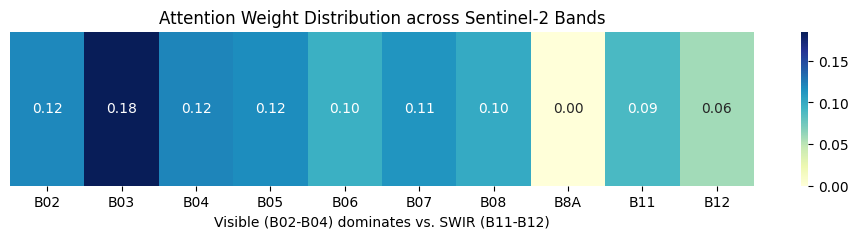

In [ ]:
# [AnySat]
# Band            raw_delta      norm_score
# ------------------------------------------
# l89/B4              5.457371     0.288777
# l89/B5              4.589929     0.242876
# l89/B3              2.835595     0.150046
# l89/B1              1.907128     0.100916
# l89/B2              1.570050     0.083079
# l89/B6              1.437221     0.076051
# l89/B7              1.100928     0.058256

# [AnySat]
# Band            raw_delta      norm_score
# ------------------------------------------
# B3                  1.311535     0.184871
# B4                  0.857291     0.120842
# B2                  0.850287     0.119855
# B5                  0.832079     0.117288
# B7                  0.800172     0.112791
# B8                  0.710336     0.100128
# B6                  0.684233     0.096448
# B11                 0.633667     0.089320
# B12                 0.414712     0.058457
# B8A                 0.000000     0.000000
# EarthPT
# B8                  0.244645     0.141357
# B12                 0.240631     0.139038
# B3                  0.208358     0.120390
# B2                  0.198969     0.114965
# B6                  0.198411     0.114643
# B11                 0.185469     0.107165
# B5                  0.164941     0.095304
# B4                  0.148382     0.085736
# B7                  0.140880     0.081402
# B8A                 0.000000     0.000000
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data from your results
bands = ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"]
scores = [0.114965, 0.120390, 0.120842, 0.117288, 0.096448, 0.112791, 0.100128, 0.000000, 0.089320, 0.058457]

# bands = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12"]
# scores = [0.0336, 0.1527, 0.1551, 0.1347, 0.0306, 0.0282, 0.0280, 0.0913, 0.1615, 0.0359, 0.0693, 0.0791]
# bands = ["B01", "B02", "B03", "B04", "B05", "B06", "B07"]
# scores = [0.100916, 0.083079, 0.150046, 0.288777, 0.288777, 0.076051, 0.058256]

plt.figure(figsize=(12, 2))
sns.heatmap([scores], annot=True, fmt=".2f", cmap="YlGnBu", xticklabels=bands, yticklabels=False)
plt.title("Attention Weight Distribution across Sentinel-2 Bands")
plt.xlabel("Visible (B02-B04) dominates vs. SWIR (B11-B12)")
# plt.title("Attention Weight Distribution across Landast-8/9 Bands")
# plt.xlabel("Visible (B02-B04) dominates vs. SWIR (B06-B07)")
plt.show()

In [2]:
#!/usr/bin/env python3
"""
按 sensor 做空间聚类并重新划分 train/test。

核心规则：
1) 先把每个 sensor 的原始 train/test 合并。
2) 硬去重：完全相同经纬度 (lat/lon) 的样本先折叠为原子组，保证最终一定在同一集合。
3) 用 DBSCAN(haversine) 在经纬度上聚类，cluster 作为 group 进行划分，避免空间泄露。
4) 动态 epsilon：以 2 * tile_edge_m 为基准，优先尝试较小半径；在满足测试比例误差容忍时优先用更小 epsilon。
5) 可视化每个 sensor 的 cluster 分布与最终 train/test 分布。

运行前依赖：
    pip install pandas numpy scikit-learn matplotlib

运行：
    python spatial_cluster_resplit.py
"""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN

EARTH_RADIUS_M = 6371008.8

# -----------------------------
# 1) 在这里改你的输入路径
# -----------------------------
SENSOR_CONFIG: Dict[str, Dict[str, object]] = {
    "l89": {
        "train_csv": "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_16_resized_to_224_CRSfixed/train_2025_balanced.csv",
        "test_csv": "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_16_resized_to_224_CRSfixed/test_filtered_2025.csv",
        "tile_edge_m": 480.0,  # 16 * 30m
    },
    "s2": {
        "train_csv": "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s2_90360_temporal_CDSE0_gee90360_2024_16/train.csv",
        "test_csv": "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s2_90360_temporal_CDSE0_gee90360_2024_16/test.csv",
        "tile_edge_m": 160.0,  # 16 * 10m
    },
    "s5p": {
        "train_csv": "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s5p_patches_3x3_to_224_offl_triplet/train.csv",
        "test_csv": "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s5p_patches_3x3_to_224_offl_triplet/test.csv",
        "tile_edge_m": 21000.0,  # 约 3 * 7km
    },
    "wv3": {
        "train_csv": "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/emit_wv3_temporal_-90_-180_16_to_224/train_balanced.csv",
        "test_csv": "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/emit_wv3_temporal_-90_-180_16_to_224/test_balanced.csv",
        "tile_edge_m": 960.0,  # 如用 16 * 60m
    },
}

# 输出目录
OUT_DIR = Path("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/datasets_mixed_training")
# 混合输出文件名（你提到的 teat_4.csv 很可能是 test_4.csv，这里默认写 test_4_geo.csv）
MIXED_TRAIN_OUT = "train_4_geo.csv"
MIXED_TEST_OUT = "test_4_geo.csv"

# 划分参数
TEST_RATIO = 0.20
RANDOM_SEED = 42
BLIND_GAP_M = 20.0  # 视觉盲区；>0 时更保守
EPS_FACTORS = (0.70, 0.85, 1.00, 1.15, 1.30)  # 动态半径候选，优先小半径
RATIO_TOL = 0.03


LAT_CANDIDATES = ("latitude", "lat", "plume_latitude")
LON_CANDIDATES = ("longitude", "lon", "plume_longitude")
@dataclass
class SplitResult:
    sensor: str
    eps_m: float
    n_clusters: int
    train_df: pd.DataFrame
    test_df: pd.DataFrame


def pick_first_existing(columns: Iterable[str], candidates: Sequence[str]) -> Optional[str]:
    colset = set(columns)
    for c in candidates:
        if c in colset:
            return c
    return None


def ensure_sensor_column(df: pd.DataFrame, sensor: str) -> pd.DataFrame:
    if "sensor" not in df.columns:
        df = df.copy()
        df["sensor"] = sensor
    return df


def normalize_latlon_columns(df: pd.DataFrame) -> Tuple[pd.DataFrame, str, str]:
    lat_col = pick_first_existing(df.columns, LAT_CANDIDATES)
    lon_col = pick_first_existing(df.columns, LON_CANDIDATES)
    if lat_col is None or lon_col is None:
        raise ValueError(
            f"找不到经纬度列。现有列: {list(df.columns)}；支持候选 lat={LAT_CANDIDATES}, lon={LON_CANDIDATES}"
        )

    out = df.copy()
    out["_lat"] = pd.to_numeric(out[lat_col], errors="coerce")
    out["_lon"] = pd.to_numeric(out[lon_col], errors="coerce")
    out = out.dropna(subset=["_lat", "_lon"])
    return out, lat_col, lon_col


def dbscan_cluster_haversine(lat_lon_deg: np.ndarray, eps_m: float) -> np.ndarray:
    # lat_lon_deg shape: (N,2), columns [lat, lon]
    radians = np.radians(lat_lon_deg)
    eps_rad = eps_m / EARTH_RADIUS_M
    # min_samples=1: 无噪声点，所有点都归到某个 cluster
    labels = DBSCAN(eps=eps_rad, min_samples=1, metric="haversine").fit_predict(radians)
    return labels


def greedy_split_by_cluster(df: pd.DataFrame, cluster_col: str, test_ratio: float, seed: int) -> pd.Series:
    """返回 bool 序列: True 表示进入 test。"""
    rng = np.random.default_rng(seed)

    # cluster-level 统计
    cluster_stats = (
        df.groupby(cluster_col)
        .agg(n=(cluster_col, "size"), pos=("label", "sum"))
        .reset_index()
    )

    # 随机打散后按大 cluster 优先分配，避免最后被大块卡住
    cluster_stats = cluster_stats.sample(frac=1.0, random_state=seed).sort_values("n", ascending=False)

    total_n = int(cluster_stats["n"].sum())
    total_pos = float(cluster_stats["pos"].sum())
    target_test_n = total_n * test_ratio
    target_test_pos = total_pos * test_ratio

    test_clusters = set()
    test_n = 0
    test_pos = 0.0

    for _, row in cluster_stats.iterrows():
        cid = row[cluster_col]
        n = int(row["n"])
        pos = float(row["pos"])

        # 选择代价：样本比例误差 + 正样本比例误差
        keep_cost = abs(test_n - target_test_n) + 1.2 * abs(test_pos - target_test_pos)
        take_cost = abs((test_n + n) - target_test_n) + 1.2 * abs((test_pos + pos) - target_test_pos)

        # 轻微随机扰动，避免完全同分时固定模式
        jitter = rng.uniform(-1e-6, 1e-6)
        if take_cost + jitter < keep_cost:
            test_clusters.add(cid)
            test_n += n
            test_pos += pos

    # 兜底：避免全进 train 或全进 test
    if len(test_clusters) == 0 and len(cluster_stats) > 0:
        test_clusters.add(cluster_stats.iloc[0][cluster_col])
    if len(test_clusters) == len(cluster_stats) and len(cluster_stats) > 1:
        test_clusters.remove(cluster_stats.iloc[-1][cluster_col])

    return df[cluster_col].isin(test_clusters)


def evaluate_split(df: pd.DataFrame, is_test: pd.Series, test_ratio: float) -> float:
    total = len(df)
    if total == 0:
        return float("inf")

    global_pos = float(df["label"].mean()) if "label" in df.columns else 0.0
    test_df = df[is_test]
    test_frac = len(test_df) / total
    test_pos = float(test_df["label"].mean()) if len(test_df) > 0 else global_pos

    ratio_err = abs(test_frac - test_ratio)
    label_err = abs(test_pos - global_pos)
    return ratio_err + 0.5 * label_err


def split_one_sensor(
    sensor: str,
    train_csv: str,
    test_csv: str,
    tile_edge_m: float,
    test_ratio: float,
    blind_gap_m: float,
    eps_factors: Sequence[float],
    ratio_tol: float,
    seed: int,
) -> SplitResult:
    train_df = pd.read_csv(train_csv)
    test_df = pd.read_csv(test_csv)

    train_df = ensure_sensor_column(train_df, sensor)
    test_df = ensure_sensor_column(test_df, sensor)

    train_df["_orig_split"] = "train"
    test_df["_orig_split"] = "test"
    df = pd.concat([train_df, test_df], ignore_index=True)

    df, lat_col, lon_col = normalize_latlon_columns(df)

    if "label" not in df.columns:
        raise ValueError(f"{sensor}: 缺少 label 列，无法做分层质量评估。")

    # -----------------------------
    # 硬去重：完全相同经纬度点先合并
    # -----------------------------
    # 用字符串键锁死“完全一样”的坐标，确保多时相/重复样本一起分配
    df["_coord_key"] = df[lat_col].astype(str).str.strip() + "|" + df[lon_col].astype(str).str.strip()
    coord_df = df.groupby("_coord_key", as_index=False).agg({"_lat": "first", "_lon": "first"})

    base_eps = 2.0 * float(tile_edge_m) + float(blind_gap_m)

    best = None
    candidate_records: List[Tuple[float, float, pd.Series, np.ndarray]] = []

    for factor in sorted(eps_factors):
        eps_m = base_eps * float(factor)

        coord_labels = dbscan_cluster_haversine(coord_df[["_lat", "_lon"]].to_numpy(), eps_m=eps_m)
        coord_df_tmp = coord_df.copy()
        coord_df_tmp["_cluster_id"] = coord_labels

        # 映射回每行样本
        key2cluster = dict(zip(coord_df_tmp["_coord_key"], coord_df_tmp["_cluster_id"]))
        df_tmp = df.copy()
        df_tmp["_cluster_id"] = df_tmp["_coord_key"].map(key2cluster)

        is_test = greedy_split_by_cluster(df_tmp, "_cluster_id", test_ratio=test_ratio, seed=seed)
        quality = evaluate_split(df_tmp, is_test, test_ratio=test_ratio)
        candidate_records.append((eps_m, quality, is_test, coord_labels))

    # 优先选满足测试占比误差的最小 eps；否则选质量最佳且 eps 小者
    feasible = []
    for eps_m, quality, is_test, coord_labels in candidate_records:
        frac = float(is_test.mean())
        if abs(frac - test_ratio) <= ratio_tol:
            feasible.append((eps_m, quality, is_test, coord_labels))

    if feasible:
        feasible.sort(key=lambda x: (x[0], x[1]))  # 更小 eps 优先
        best = feasible[0]
    else:
        candidate_records.sort(key=lambda x: (x[1], x[0]))
        best = candidate_records[0]

    best_eps_m, _, best_is_test, best_coord_labels = best

    # 再构建最终 cluster_id（对应 best eps）
    final_coord_df = coord_df.copy()
    final_coord_df["_cluster_id"] = best_coord_labels
    key2cluster = dict(zip(final_coord_df["_coord_key"], final_coord_df["_cluster_id"]))
    df["cluster_id"] = df["_coord_key"].map(key2cluster)
    df["split"] = np.where(best_is_test, "test", "train")

    out_train = df[df["split"] == "train"].copy()
    out_test = df[df["split"] == "test"].copy()

    # 清理临时列
    drop_cols = ["_lat", "_lon", "_coord_key", "_orig_split", "split"]
    out_train = out_train.drop(columns=[c for c in drop_cols if c in out_train.columns])
    out_test = out_test.drop(columns=[c for c in drop_cols if c in out_test.columns])

    n_clusters = int(final_coord_df["_cluster_id"].nunique())
    return SplitResult(sensor=sensor, eps_m=best_eps_m, n_clusters=n_clusters, train_df=out_train, test_df=out_test)


def plot_sensor_clusters(
    sensor: str,
    full_df: pd.DataFrame,
    out_png: Path,
    lat_col: str = "_lat",
    lon_col: str = "_lon",
):
    out_png.parent.mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=150)

    # 左图：cluster 分布
    axes[0].scatter(
        full_df[lon_col],
        full_df[lat_col],
        c=full_df["cluster_id"].astype(int),
        s=6,
        cmap="tab20",
        alpha=0.75,
        linewidths=0,
    )
    axes[0].set_title(f"{sensor}: Spatial Clusters")
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")

    # 右图：train/test 分布
    split_color = np.where(full_df["split"] == "test", "#D62728", "#1F77B4")
    axes[1].scatter(
        full_df[lon_col],
        full_df[lat_col],
        c=split_color,
        s=6,
        alpha=0.75,
        linewidths=0,
    )
    axes[1].set_title(f"{sensor}: Train/Test by Cluster")
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")

    train_n = int((full_df["split"] == "train").sum())
    test_n = int((full_df["split"] == "test").sum())
    axes[1].text(
        0.01,
        0.99,
        f"train={train_n}, test={test_n}",
        transform=axes[1].transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
    )

    plt.tight_layout()
    plt.savefig(out_png, bbox_inches="tight")
    plt.close(fig)


def run() -> None:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    viz_dir = OUT_DIR / "cluster_viz"
    viz_dir.mkdir(parents=True, exist_ok=True)

    all_train: List[pd.DataFrame] = []
    all_test: List[pd.DataFrame] = []

    print("=" * 90)
    print("Spatial cluster split started")
    print(f"Output dir: {OUT_DIR}")
    print("=" * 90)

    for sensor, cfg in SENSOR_CONFIG.items():
        train_csv = str(cfg["train_csv"])
        test_csv = str(cfg["test_csv"])
        tile_edge_m = float(cfg["tile_edge_m"])

        print(f"\n[{sensor}] loading")
        print(f"  train: {train_csv}")
        print(f"  test : {test_csv}")

        split_res = split_one_sensor(
            sensor=sensor,
            train_csv=train_csv,
            test_csv=test_csv,
            tile_edge_m=tile_edge_m,
            test_ratio=TEST_RATIO,
            blind_gap_m=BLIND_GAP_M,
            eps_factors=EPS_FACTORS,
            ratio_tol=RATIO_TOL,
            seed=RANDOM_SEED,
        )

        sensor_train_out = OUT_DIR / f"train_{sensor}_geo.csv"
        sensor_test_out = OUT_DIR / f"test_{sensor}_geo.csv"
        split_res.train_df.to_csv(sensor_train_out, index=False)
        split_res.test_df.to_csv(sensor_test_out, index=False)

        print(
            f"  eps={split_res.eps_m:.1f}m, clusters={split_res.n_clusters}, "
            f"train={len(split_res.train_df)}, test={len(split_res.test_df)}"
        )
        print(f"  -> {sensor_train_out}")
        print(f"  -> {sensor_test_out}")

        all_train.append(split_res.train_df)
        all_test.append(split_res.test_df)

        # 可视化需要复建 full_df（保留中间列）
        # 这里直接重算一次，避免在返回对象里塞过大临时 DataFrame。
        merged = pd.concat([
            ensure_sensor_column(pd.read_csv(train_csv), sensor),
            ensure_sensor_column(pd.read_csv(test_csv), sensor),
        ], ignore_index=True)
        merged, lat_col, lon_col = normalize_latlon_columns(merged)
        merged["_coord_key"] = merged[lat_col].astype(str).str.strip() + "|" + merged[lon_col].astype(str).str.strip()
        coord_df = merged.groupby("_coord_key", as_index=False).agg({"_lat": "first", "_lon": "first"})
        coord_labels = dbscan_cluster_haversine(coord_df[["_lat", "_lon"]].to_numpy(), split_res.eps_m)
        key2cluster = dict(zip(coord_df["_coord_key"], coord_labels))
        merged["cluster_id"] = merged["_coord_key"].map(key2cluster)

        # 用最终 train/test 的索引键回填 split 标记
        # 优先用常见 id 列；没有就退化到 path_t0
        key_col = None
        for cand in ("id", "sample_id", "path_t0"):
            if cand in merged.columns and cand in split_res.train_df.columns and cand in split_res.test_df.columns:
                key_col = cand
                break
        if key_col is None:
            warnings.warn(f"{sensor}: 找不到稳定主键用于回填 split，可视化将按 cluster 随机示意。")
            mask_test = greedy_split_by_cluster(merged, "cluster_id", test_ratio=TEST_RATIO, seed=RANDOM_SEED)
            merged["split"] = np.where(mask_test, "test", "train")
        else:
            train_keys = set(split_res.train_df[key_col].astype(str))
            merged["split"] = np.where(merged[key_col].astype(str).isin(train_keys), "train", "test")

        plot_path = viz_dir / f"{sensor}_cluster_split.png"
        plot_sensor_clusters(sensor=sensor, full_df=merged, out_png=plot_path)
        print(f"  -> {plot_path}")

    mixed_train = pd.concat(all_train, ignore_index=True)
    mixed_test = pd.concat(all_test, ignore_index=True)

    mixed_train_out = OUT_DIR / MIXED_TRAIN_OUT
    mixed_test_out = OUT_DIR / MIXED_TEST_OUT
    mixed_train.to_csv(mixed_train_out, index=False)
    mixed_test.to_csv(mixed_test_out, index=False)

    print("\n" + "=" * 90)
    print(f"Mixed train -> {mixed_train_out} ({len(mixed_train)} rows)")
    print(f"Mixed test  -> {mixed_test_out} ({len(mixed_test)} rows)")
    print("Done.")


if __name__ == "__main__":
    run()


Spatial cluster split started
Output dir: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/datasets_mixed_training

[l89] loading
  train: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_16_resized_to_224_CRSfixed/train_2025_balanced.csv
  test : /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_16_resized_to_224_CRSfixed/test_filtered_2025.csv
  eps=686.0m, clusters=1379, train=48702, test=12208
  -> /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/datasets_mixed_training/train_l89_geo.csv
  -> /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/datasets_mixed_training/test_l89_geo.csv
  -> /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/datasets_mixed_training/cluster_viz/l89_cluster_split.png

[s2] loading
  train: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s2_90360_temporal_CDSE0_gee90360_2024_16/train.csv
  test : /mnt/engg-leung/Res

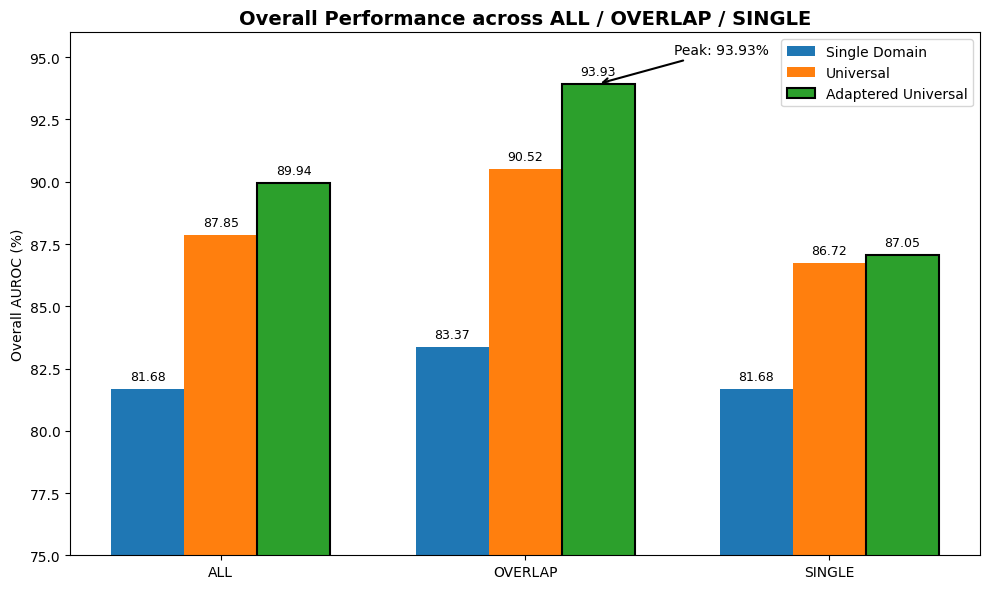

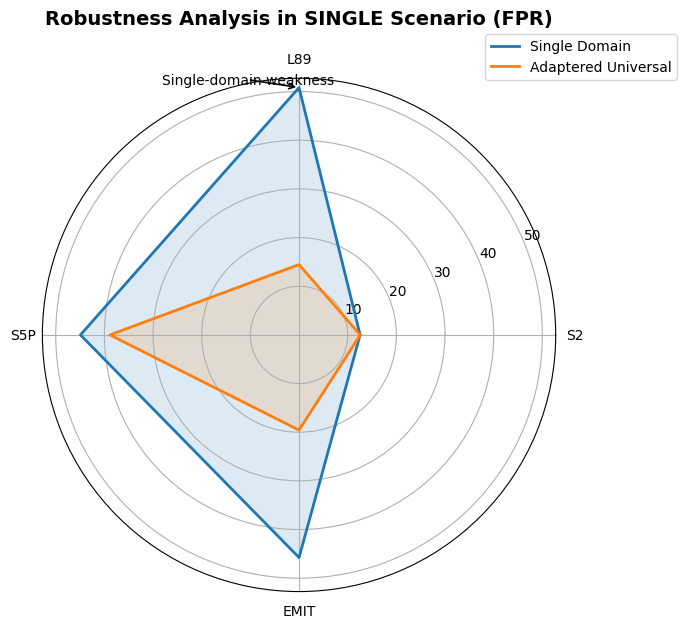

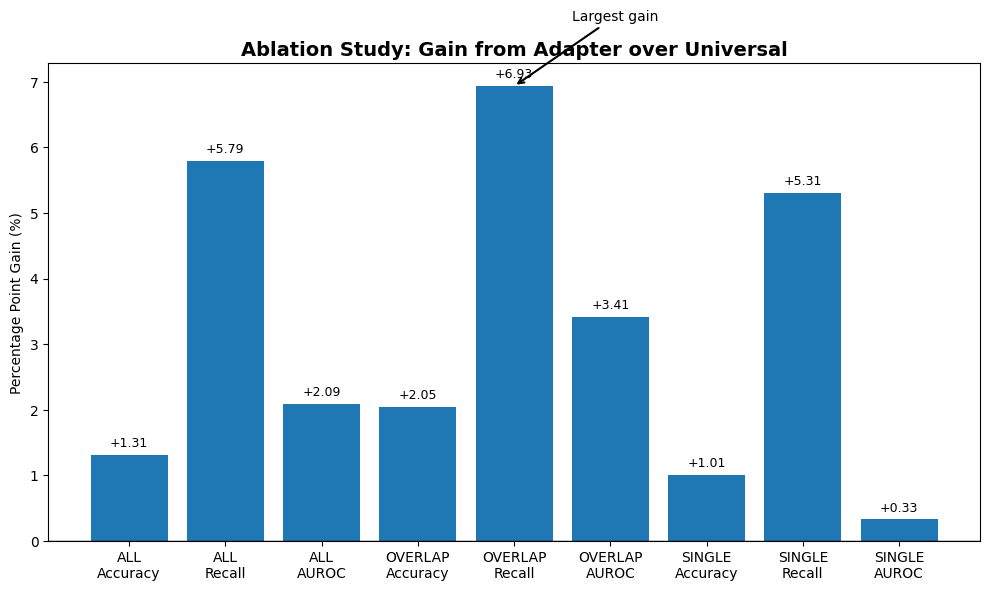

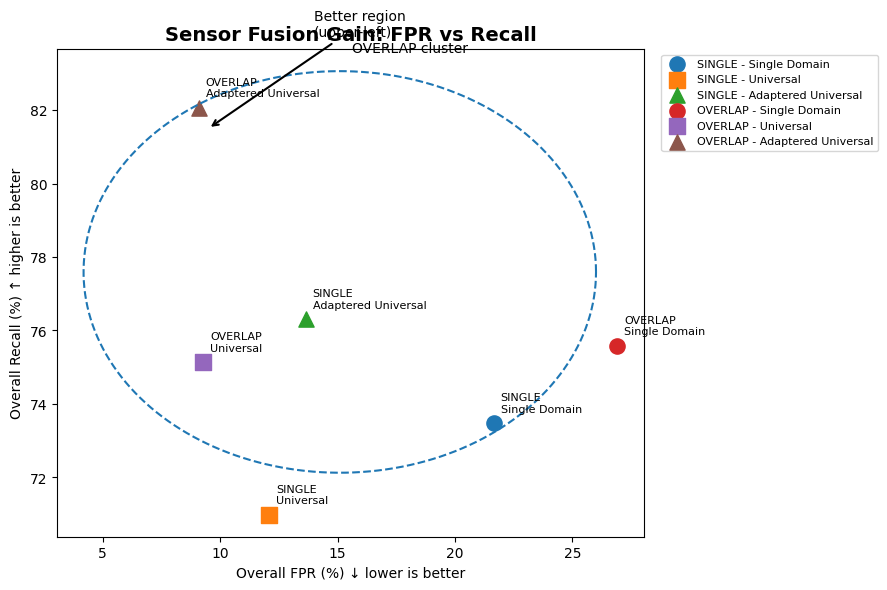

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. 原始数据整理
# =========================

data = {
    "ALL": {
        "Single Domain": {
            "overall_acc": 72.22, "overall_fpr": 21.64, "overall_recall": 73.48, "overall_auroc": 81.68,
            "s2_acc": 87.32, "s2_fpr": 11.96,
            "l89_acc": 74.07, "l89_fpr": 21.93,
            "s5p_acc": 65.54, "s5p_fpr": 30.70,
            "emit_acc": 62.61, "emit_fpr": 46.44
        },
        "Universal": {
            "overall_acc": 80.12, "overall_fpr": 11.26, "overall_recall": 72.17, "overall_auroc": 87.85,
            "s2_acc": 85.86, "s2_fpr": 7.89,
            "l89_acc": 74.32, "l89_fpr": 10.86,
            "s5p_acc": 79.92, "s5p_fpr": 15.15,
            "emit_acc": 80.15, "emit_fpr": 12.16
        },
        "Adaptered Universal": {
            "overall_acc": 81.43, "overall_fpr": 12.33, "overall_recall": 77.96, "overall_auroc": 89.94,
            "s2_acc": 87.11, "s2_fpr": 13.10,
            "l89_acc": 76.46, "l89_fpr": 12.25,
            "s5p_acc": 80.74, "s5p_fpr": 13.62,
            "emit_acc": 80.26, "emit_fpr": 16.64
        }
    },
    "OVERLAP": {
        "Single Domain": {
            "overall_acc": 74.38, "overall_fpr": 26.91, "overall_recall": 75.59, "overall_auroc": 83.37,
            "s2_acc": 88.15, "s2_fpr": 13.74,
            "l89_acc": 73.10, "l89_fpr": 24.27,
            "s5p_acc": 65.85, "s5p_fpr": 28.57,
            "emit_acc": 61.18, "emit_fpr": 49.27
        },
        "Universal": {
            "overall_acc": 82.70, "overall_fpr": 9.28, "overall_recall": 75.13, "overall_auroc": 90.52,
            "s2_acc": 87.21, "s2_fpr": 8.75,
            "l89_acc": 77.29, "l89_fpr": 8.10,
            "s5p_acc": 83.00, "s5p_fpr": 10.76,
            "emit_acc": 81.56, "emit_fpr": 8.52
        },
        "Adaptered Universal": {
            "overall_acc": 84.75, "overall_fpr": 9.09, "overall_recall": 82.06, "overall_auroc": 93.93,
            "s2_acc": 88.26, "s2_fpr": 14.08,
            "l89_acc": 80.90, "l89_fpr": 8.89,
            "s5p_acc": 83.21, "s5p_fpr": 9.83,
            "emit_acc": 83.13, "emit_fpr": 9.05
        }
    },
    "SINGLE": {
        "Single Domain": {
            "overall_acc": 72.22, "overall_fpr": 21.64, "overall_recall": 73.48, "overall_auroc": 81.68,
            "s2_acc": 86.47, "s2_fpr": 12.55,
            "l89_acc": 64.33, "l89_fpr": 50.83,
            "s5p_acc": 65.05, "s5p_fpr": 44.92,
            "emit_acc": 62.92, "emit_fpr": 45.76
        },
        "Universal": {
            "overall_acc": 79.07, "overall_fpr": 12.08, "overall_recall": 70.99, "overall_auroc": 86.72,
            "s2_acc": 85.11, "s2_fpr": 7.41,
            "l89_acc": 72.09, "l89_fpr": 12.88,
            "s5p_acc": 59.42, "s5p_fpr": 44.73,
            "emit_acc": 79.63, "emit_fpr": 13.57
        },
        "Adaptered Universal": {
            "overall_acc": 80.08, "overall_fpr": 13.64, "overall_recall": 76.30, "overall_auroc": 87.05,
            "s2_acc": 86.46, "s2_fpr": 12.57,
            "l89_acc": 73.14, "l89_fpr": 14.45,
            "s5p_acc": 64.29, "s5p_fpr": 38.87,
            "emit_acc": 79.21, "emit_fpr": 19.57
        }
    }
}

# 可选：如果你的环境支持中文字体，可以取消下面注释
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'Microsoft YaHei']
# plt.rcParams['axes.unicode_minus'] = False


# =========================
# 2. 核心结论图：Overall AUROC 分组柱状图
# =========================
scenes = ["ALL", "OVERLAP", "SINGLE"]
models = ["Single Domain", "Universal", "Adaptered Universal"]

overall_auroc = {
    model: [data[scene][model]["overall_auroc"] for scene in scenes]
    for model in models
}

x = np.arange(len(scenes))
width = 0.24

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width, overall_auroc["Single Domain"], width, label="Single Domain")
bars2 = ax.bar(x, overall_auroc["Universal"], width, label="Universal")
bars3 = ax.bar(x + width, overall_auroc["Adaptered Universal"], width, label="Adaptered Universal")

# 高亮 Adaptered Universal
for bar in bars3:
    bar.set_linewidth(1.5)
    bar.set_edgecolor("black")

ax.set_title("Overall Performance across ALL / OVERLAP / SINGLE", fontsize=14, weight='bold')
ax.set_ylabel("Overall AUROC (%)")
ax.set_xticks(x)
ax.set_xticklabels(scenes)
ax.set_ylim(75, 96)
ax.legend()

# 数值标注
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.25, f"{h:.2f}",
                ha='center', va='bottom', fontsize=9)

# 特别标注性能巅峰
peak_x = x[1] + width
peak_y = data["OVERLAP"]["Adaptered Universal"]["overall_auroc"]
ax.annotate("Peak: 93.93%",
            xy=(peak_x, peak_y),
            xytext=(peak_x + 0.25, peak_y + 1.2),
            arrowprops=dict(arrowstyle="->", lw=1.5),
            fontsize=10)

plt.tight_layout()
plt.show()


# =========================
# 3. 鲁棒性分析图：SINGLE场景 FPR 雷达图
# =========================
categories = ["s2_fpr", "l89_fpr", "s5p_fpr", "emit_fpr"]
labels = ["S2", "L89", "S5P", "EMIT"]

single_domain_vals = [data["SINGLE"]["Single Domain"][c] for c in categories]
adapter_vals = [data["SINGLE"]["Adaptered Universal"][c] for c in categories]

# 闭合图形
single_domain_vals += single_domain_vals[:1]
adapter_vals += adapter_vals[:1]

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)

ax.plot(angles, single_domain_vals, linewidth=2, label="Single Domain")
ax.fill(angles, single_domain_vals, alpha=0.15)

ax.plot(angles, adapter_vals, linewidth=2, label="Adaptered Universal")
ax.fill(angles, adapter_vals, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title("Robustness Analysis in SINGLE Scenario (FPR)", fontsize=14, weight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.10))

# 标出最严重“偏科”
worst_idx = np.argmax(single_domain_vals[:-1])
ax.annotate("Single-domain weakness",
            xy=(angles[worst_idx], single_domain_vals[worst_idx]),
            xytext=(angles[worst_idx] + 0.5, single_domain_vals[worst_idx] + 8),
            arrowprops=dict(arrowstyle="->", lw=1.2),
            fontsize=10)

plt.tight_layout()
plt.show()


# =========================
# 4. 消融实验图：Adapter 带来的增益
# 这里画 ALL / OVERLAP / SINGLE 的整体指标提升
# =========================
metrics = ["overall_acc", "overall_recall", "overall_auroc"]
metric_names = ["Accuracy", "Recall", "AUROC"]

gain_records = []
for scene in scenes:
    uni = data[scene]["Universal"]
    adp = data[scene]["Adaptered Universal"]
    for m, mname in zip(metrics, metric_names):
        gain_records.append({
            "Scene": scene,
            "Metric": mname,
            "Gain": adp[m] - uni[m]
        })

gain_df = pd.DataFrame(gain_records)

fig, ax = plt.subplots(figsize=(10, 6))

bar_positions = np.arange(len(gain_df))
bars = ax.bar(bar_positions, gain_df["Gain"])

ax.axhline(0, color='black', linewidth=1)
ax.set_title("Ablation Study: Gain from Adapter over Universal", fontsize=14, weight='bold')
ax.set_ylabel("Percentage Point Gain (%)")
ax.set_xticks(bar_positions)
ax.set_xticklabels(
    [f"{row.Scene}\n{row.Metric}" for _, row in gain_df.iterrows()],
    rotation=0
)

# 标数值 + 最显著提升
max_gain_idx = gain_df["Gain"].idxmax()

for i, (bar, gain) in enumerate(zip(bars, gain_df["Gain"])):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            h + 0.08 if h >= 0 else h - 0.25,
            f"{h:+.2f}",
            ha='center',
            va='bottom' if h >= 0 else 'top',
            fontsize=9)

    if i == max_gain_idx:
        ax.annotate("Largest gain",
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(bar.get_x() + bar.get_width()/2 + 0.6, h + 1.0),
                    arrowprops=dict(arrowstyle="->", lw=1.5),
                    fontsize=10)

plt.tight_layout()
plt.show()


# =========================
# 5. 场景收益分析：FPR vs Recall 散点图
# 用 overall 指标画 SINGLE 和 OVERLAP
# 越左上越好
# =========================
plot_models = ["Single Domain", "Universal", "Adaptered Universal"]
scene_colors = {"SINGLE": "C0", "OVERLAP": "C1"}
markers = {"Single Domain": "o", "Universal": "s", "Adaptered Universal": "^"}

fig, ax = plt.subplots(figsize=(9, 6))

for scene in ["SINGLE", "OVERLAP"]:
    for model in plot_models:
        fpr = data[scene][model]["overall_fpr"]
        recall = data[scene][model]["overall_recall"]
        ax.scatter(fpr, recall, s=120, marker=markers[model], label=f"{scene} - {model}")
        ax.text(fpr + 0.3, recall + 0.3, f"{scene}\n{model}", fontsize=8)

ax.set_title("Sensor Fusion Gain: FPR vs Recall", fontsize=14, weight='bold')
ax.set_xlabel("Overall FPR (%) ↓ lower is better")
ax.set_ylabel("Overall Recall (%) ↑ higher is better")

# 高亮左上角优区
ax.annotate("Better region\n(upper-left)",
            xy=(9.5, 81.5),
            xytext=(14, 84),
            arrowprops=dict(arrowstyle="->", lw=1.5),
            fontsize=10)

# 圈出 OVERLAP 点集
overlap_points = [(data["OVERLAP"][m]["overall_fpr"], data["OVERLAP"][m]["overall_recall"]) for m in plot_models]
xs = [p[0] for p in overlap_points]
ys = [p[1] for p in overlap_points]

center_x = np.mean(xs)
center_y = np.mean(ys)
width_ellipse = max(xs) - min(xs) + 4
height_ellipse = max(ys) - min(ys) + 4

# 用 plot 画一个近似圈区域
theta = np.linspace(0, 2*np.pi, 200)
ellipse_x = center_x + (width_ellipse / 2) * np.cos(theta)
ellipse_y = center_y + (height_ellipse / 2) * np.sin(theta)
ax.plot(ellipse_x, ellipse_y, linestyle='--', linewidth=1.5)
ax.text(center_x + 0.5, center_y + height_ellipse/2 + 0.5, "OVERLAP cluster", fontsize=10)

# 图例去重
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

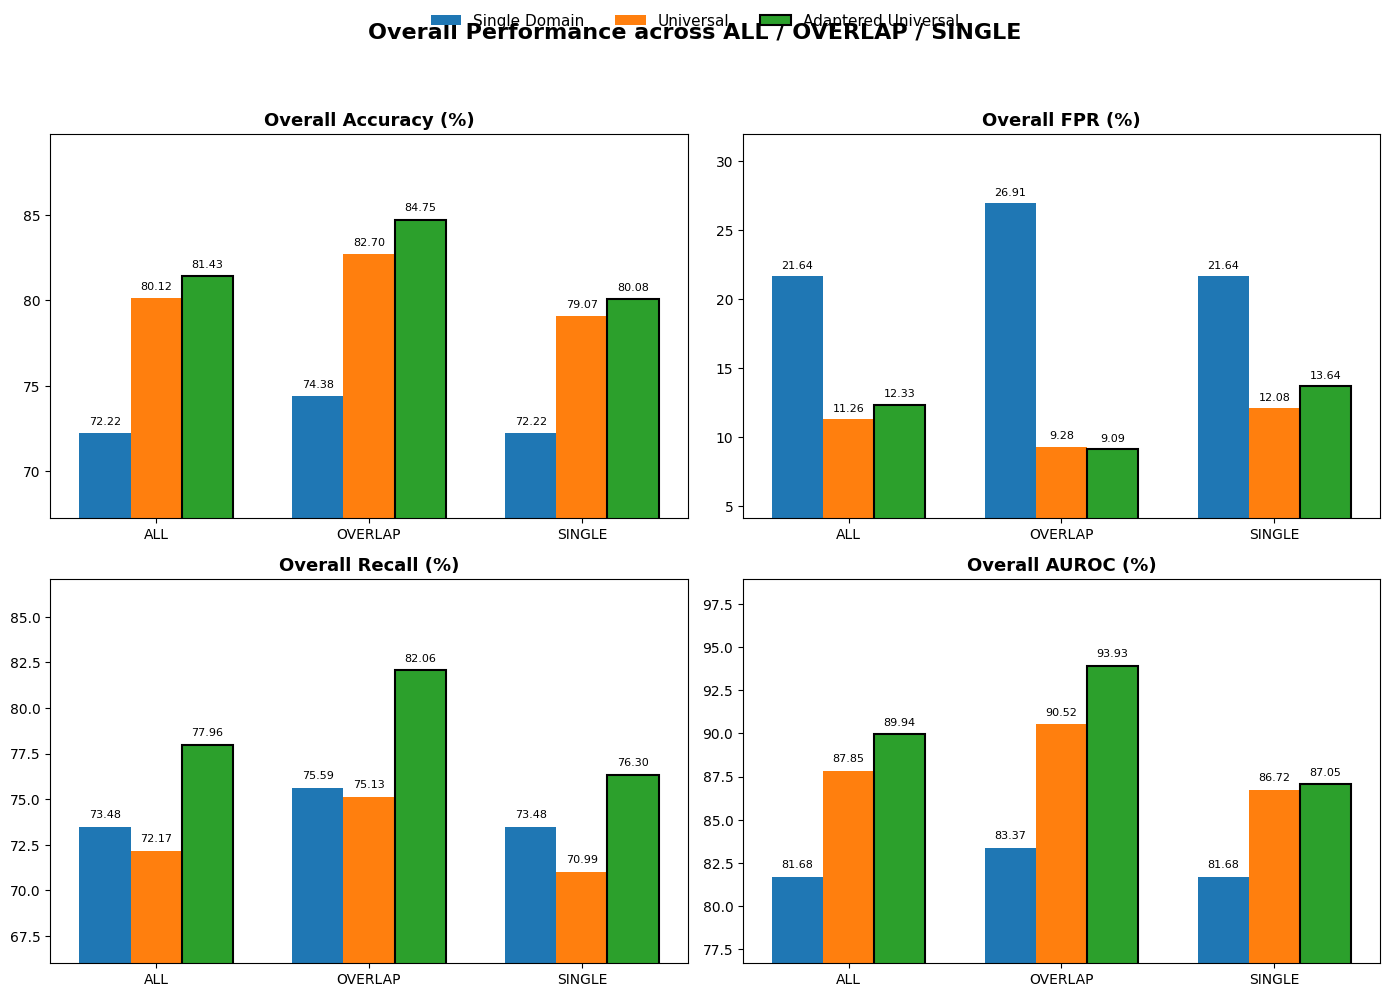

In [2]:
# =========================
# 2. 核心结论图：Overall 四指标分组柱状图
# 4个小图：Acc / FPR / Recall / AUROC
# =========================
scenes = ["ALL", "OVERLAP", "SINGLE"]
models = ["Single Domain", "Universal", "Adaptered Universal"]

metrics = [
    ("overall_acc", "Overall Accuracy (%)"),
    ("overall_fpr", "Overall FPR (%)"),
    ("overall_recall", "Overall Recall (%)"),
    ("overall_auroc", "Overall AUROC (%)")
]

x = np.arange(len(scenes))
width = 0.24

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (metric_key, metric_title) in zip(axes, metrics):
    values = {
        model: [data[scene][model][metric_key] for scene in scenes]
        for model in models
    }

    bars1 = ax.bar(x - width, values["Single Domain"], width, label="Single Domain")
    bars2 = ax.bar(x, values["Universal"], width, label="Universal")
    bars3 = ax.bar(x + width, values["Adaptered Universal"], width, label="Adaptered Universal")

    # 仅高亮 Adaptered Universal，不标最高值
    for bar in bars3:
        bar.set_linewidth(1.5)
        bar.set_edgecolor("black")

    ax.set_title(metric_title, fontsize=13, weight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(scenes)

    # 自动设置一点边距
    all_vals = values["Single Domain"] + values["Universal"] + values["Adaptered Universal"]
    ymin = max(0, min(all_vals) - 5)
    ymax = min(100, max(all_vals) + 5)
    ax.set_ylim(ymin, ymax)

    # 数值标注
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                h + 0.4,
                f"{h:.2f}",
                ha='center',
                va='bottom',
                fontsize=8
            )

# 统一图例
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=11, frameon=False)

fig.suptitle("Overall Performance across ALL / OVERLAP / SINGLE", fontsize=16, weight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

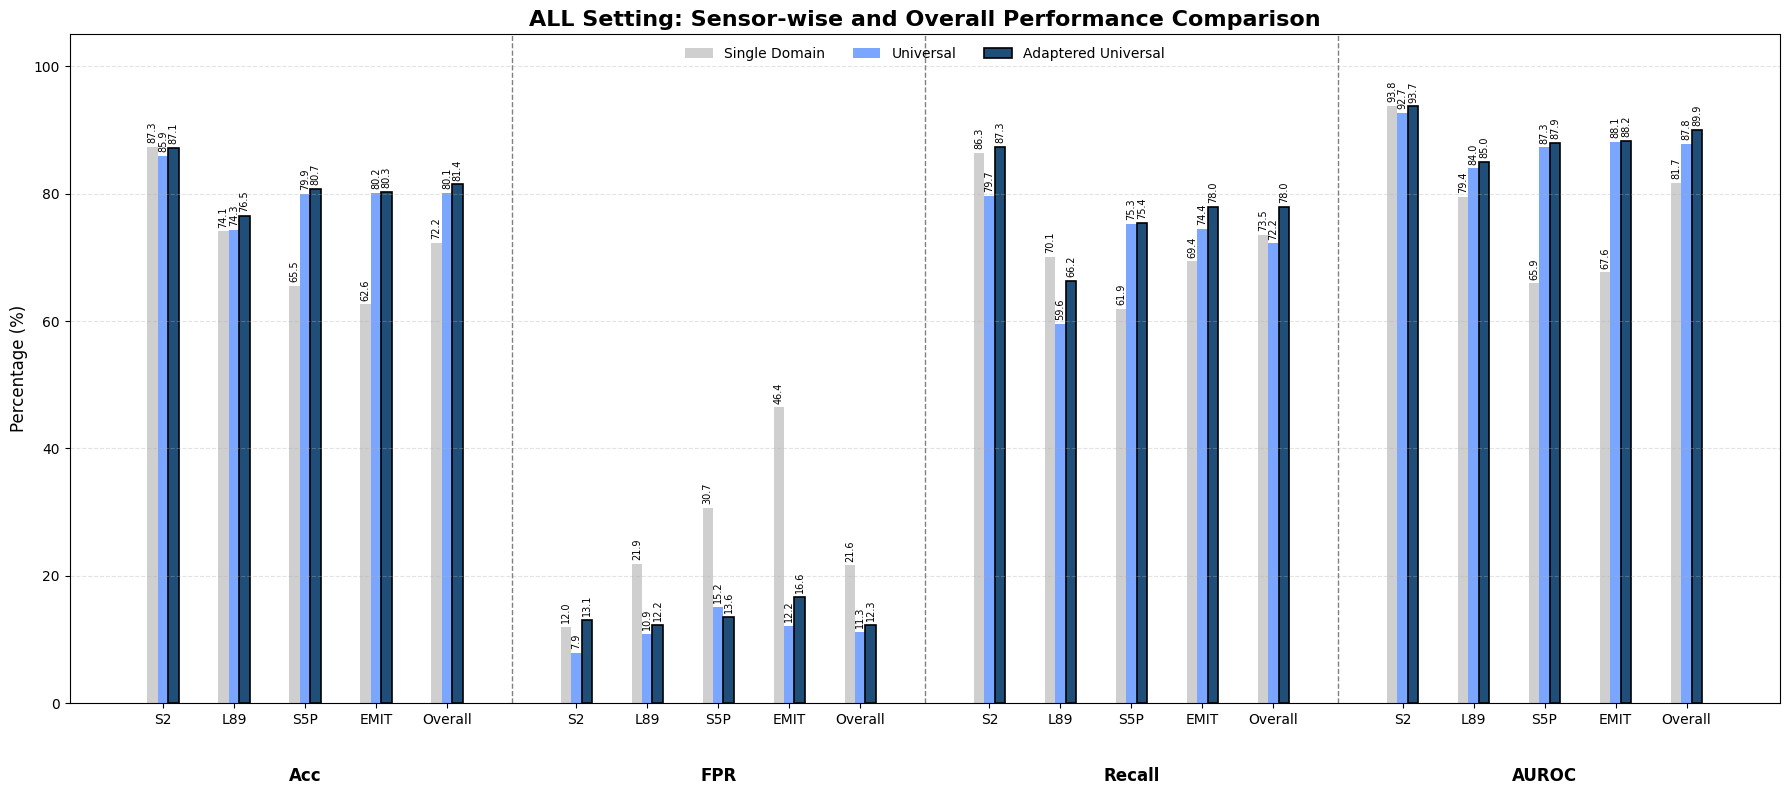

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# ALL 场景数据
# =========================
all_data = {
    "Single Domain": {
        "s2":    {"acc": 87.32, "fpr": 11.96, "recall": 86.35, "auroc": 93.76},
        "l89":   {"acc": 74.07, "fpr": 21.93, "recall": 70.10, "auroc": 79.43},
        "s5p":   {"acc": 65.54, "fpr": 30.70, "recall": 61.88, "auroc": 65.89},
        "emit":  {"acc": 62.61, "fpr": 46.44, "recall": 69.36, "auroc": 67.62},
        "overall": {"acc": 72.22, "fpr": 21.64, "recall": 73.48, "auroc": 81.68},
    },
    "Universal": {
        "s2":    {"acc": 85.86, "fpr": 7.89,  "recall": 79.65, "auroc": 92.72},
        "l89":   {"acc": 74.32, "fpr": 10.86, "recall": 59.60, "auroc": 83.95},
        "s5p":   {"acc": 79.92, "fpr": 15.15, "recall": 75.29, "auroc": 87.26},
        "emit":  {"acc": 80.15, "fpr": 12.16, "recall": 74.42, "auroc": 88.11},
        "overall": {"acc": 80.12, "fpr": 11.26, "recall": 72.17, "auroc": 87.85},
    },
    "Adaptered Universal": {
        "s2":    {"acc": 87.11, "fpr": 13.10, "recall": 87.32, "auroc": 93.68},
        "l89":   {"acc": 76.46, "fpr": 12.25, "recall": 66.25, "auroc": 84.96},
        "s5p":   {"acc": 80.74, "fpr": 13.62, "recall": 75.42, "auroc": 87.90},
        "emit":  {"acc": 80.26, "fpr": 16.64, "recall": 77.95, "auroc": 88.22},
        "overall": {"acc": 81.43, "fpr": 12.33, "recall": 77.96, "auroc": 89.94},
    }
}

models = ["Single Domain", "Universal", "Adaptered Universal"]
sensors = ["s2", "l89", "s5p", "emit", "overall"]
sensor_labels = ["S2", "L89", "S5P", "EMIT", "Overall"]
metrics = ["acc", "fpr", "recall", "auroc"]
metric_labels = ["Acc", "FPR", "Recall", "AUROC"]

colors = {
    "Single Domain": "#cfcfcf",
    "Universal": "#7aa6ff",
    "Adaptered Universal": "#1f4e79"
}

# =========================
# 一张图：ALL下所有sensor + overall，四个指标
# =========================
fig, ax = plt.subplots(figsize=(18, 8))

bar_width = 0.18
sensor_gap = 0.22
metric_gap = 1.0

x_positions = []
x_labels = []
metric_centers = []

current_x = 0

for metric in metrics:
    sensor_centers_this_metric = []

    for sensor in sensors:
        center = current_x
        sensor_centers_this_metric.append(center)

        for i, model in enumerate(models):
            value = all_data[model][sensor][metric]
            x = center + (i - 1) * bar_width

            ax.bar(
                x,
                value,
                width=bar_width,
                color=colors[model],
                edgecolor="black" if model == "Adaptered Universal" else None,
                linewidth=1.2 if model == "Adaptered Universal" else 0.8,
                label=model if (metric == "acc" and sensor == "s2") else ""
            )

            ax.text(
                x,
                value + 0.6,
                f"{value:.1f}",
                ha="center",
                va="bottom",
                fontsize=7,
                rotation=90
            )

        x_positions.append(center)
        x_labels.append(sensor_labels[sensors.index(sensor)])
        current_x += 1 + sensor_gap

    metric_centers.append(np.mean(sensor_centers_this_metric))
    current_x += metric_gap

# x轴
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=10)

# y轴和标题
ax.set_ylabel("Percentage (%)", fontsize=12)
ax.set_title("ALL Setting: Sensor-wise and Overall Performance Comparison", fontsize=16, weight="bold")
ax.set_ylim(0, 105)

# 每个 metric 下方写名字
for center, label in zip(metric_centers, metric_labels):
    ax.text(center, -10, label, ha="center", va="top", fontsize=12, weight="bold")

# metric 分隔线
for i in range(len(metric_centers) - 1):
    split_x = (metric_centers[i] + metric_centers[i + 1]) / 2
    ax.axvline(split_x, color="gray", linestyle="--", linewidth=1)

ax.legend(ncol=3, loc="upper center", frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

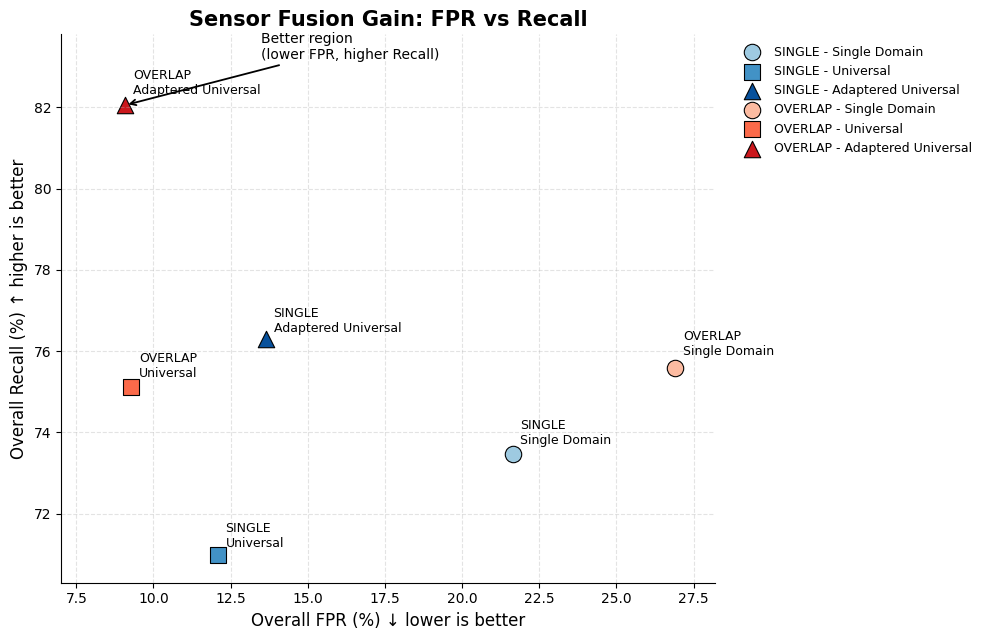

In [5]:
# =========================
# 5. 场景收益分析：更清晰的 FPR vs Recall 散点图
# =========================
import matplotlib.pyplot as plt

plot_data = [
    ("SINGLE",  "Single Domain",       21.64, 73.48),
    ("SINGLE",  "Universal",           12.08, 70.99),
    ("SINGLE",  "Adaptered Universal", 13.64, 76.30),
    ("OVERLAP", "Single Domain",       26.91, 75.59),
    ("OVERLAP", "Universal",            9.28, 75.13),
    ("OVERLAP", "Adaptered Universal",  9.09, 82.06),
]

# 颜色：SINGLE 一组蓝色系，OVERLAP 一组红色系
color_map = {
    ("SINGLE", "Single Domain"): "#9ecae1",
    ("SINGLE", "Universal"): "#4292c6",
    ("SINGLE", "Adaptered Universal"): "#08519c",
    ("OVERLAP", "Single Domain"): "#fcbba1",
    ("OVERLAP", "Universal"): "#fb6a4a",
    ("OVERLAP", "Adaptered Universal"): "#cb181d",
}

marker_map = {
    "Single Domain": "o",
    "Universal": "s",
    "Adaptered Universal": "^",
}

# 手动调整每个标签位置，避免重叠
label_offsets = {
    ("SINGLE", "Single Domain"): (0.25, 0.15),
    ("SINGLE", "Universal"): (0.25, 0.12),
    ("SINGLE", "Adaptered Universal"): (0.25, 0.10),
    ("OVERLAP", "Single Domain"): (0.25, 0.25),
    ("OVERLAP", "Universal"): (0.25, 0.15),
    ("OVERLAP", "Adaptered Universal"): (0.25, 0.20),
}

fig, ax = plt.subplots(figsize=(10, 6.5))

# 画点
for scene, model, fpr, recall in plot_data:
    ax.scatter(
        fpr, recall,
        s=140,
        color=color_map[(scene, model)],
        marker=marker_map[model],
        edgecolor="black",
        linewidth=0.8,
        label=f"{scene} - {model}"
    )

# 画标签
for scene, model, fpr, recall in plot_data:
    dx, dy = label_offsets[(scene, model)]
    ax.text(
        fpr + dx,
        recall + dy,
        f"{scene}\n{model}",
        fontsize=9,
        ha="left",
        va="bottom"
    )

# better region 注释
ax.annotate(
    "Better region\n(lower FPR, higher Recall)",
    xy=(9.1, 82.06),
    xytext=(13.5, 83.2),
    arrowprops=dict(arrowstyle="->", lw=1.3),
    fontsize=10,
    ha="left"
)

# 坐标轴
ax.set_title("Sensor Fusion Gain: FPR vs Recall", fontsize=15, weight="bold")
ax.set_xlabel("Overall FPR (%) ↓ lower is better", fontsize=12)
ax.set_ylabel("Overall Recall (%) ↑ higher is better", fontsize=12)

# 适当留白，别贴边
ax.set_xlim(7, 28.2)
ax.set_ylim(70.3, 83.8)

# 网格线帮助阅读
ax.grid(True, linestyle="--", alpha=0.35)

# 去掉上右边框，图更干净
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 图例简化并放到外面
handles, labels = ax.get_legend_handles_labels()
seen = {}
new_handles = []
new_labels = []
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = True
        new_handles.append(h)
        new_labels.append(l)

ax.legend(
    new_handles,
    new_labels,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=9
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1188532/2660250669.py:72: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1188532/2660250669.py:74: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('full_4sensors_temporal_split.png', dpi=300, transparent=False, bbox_inches='tight')


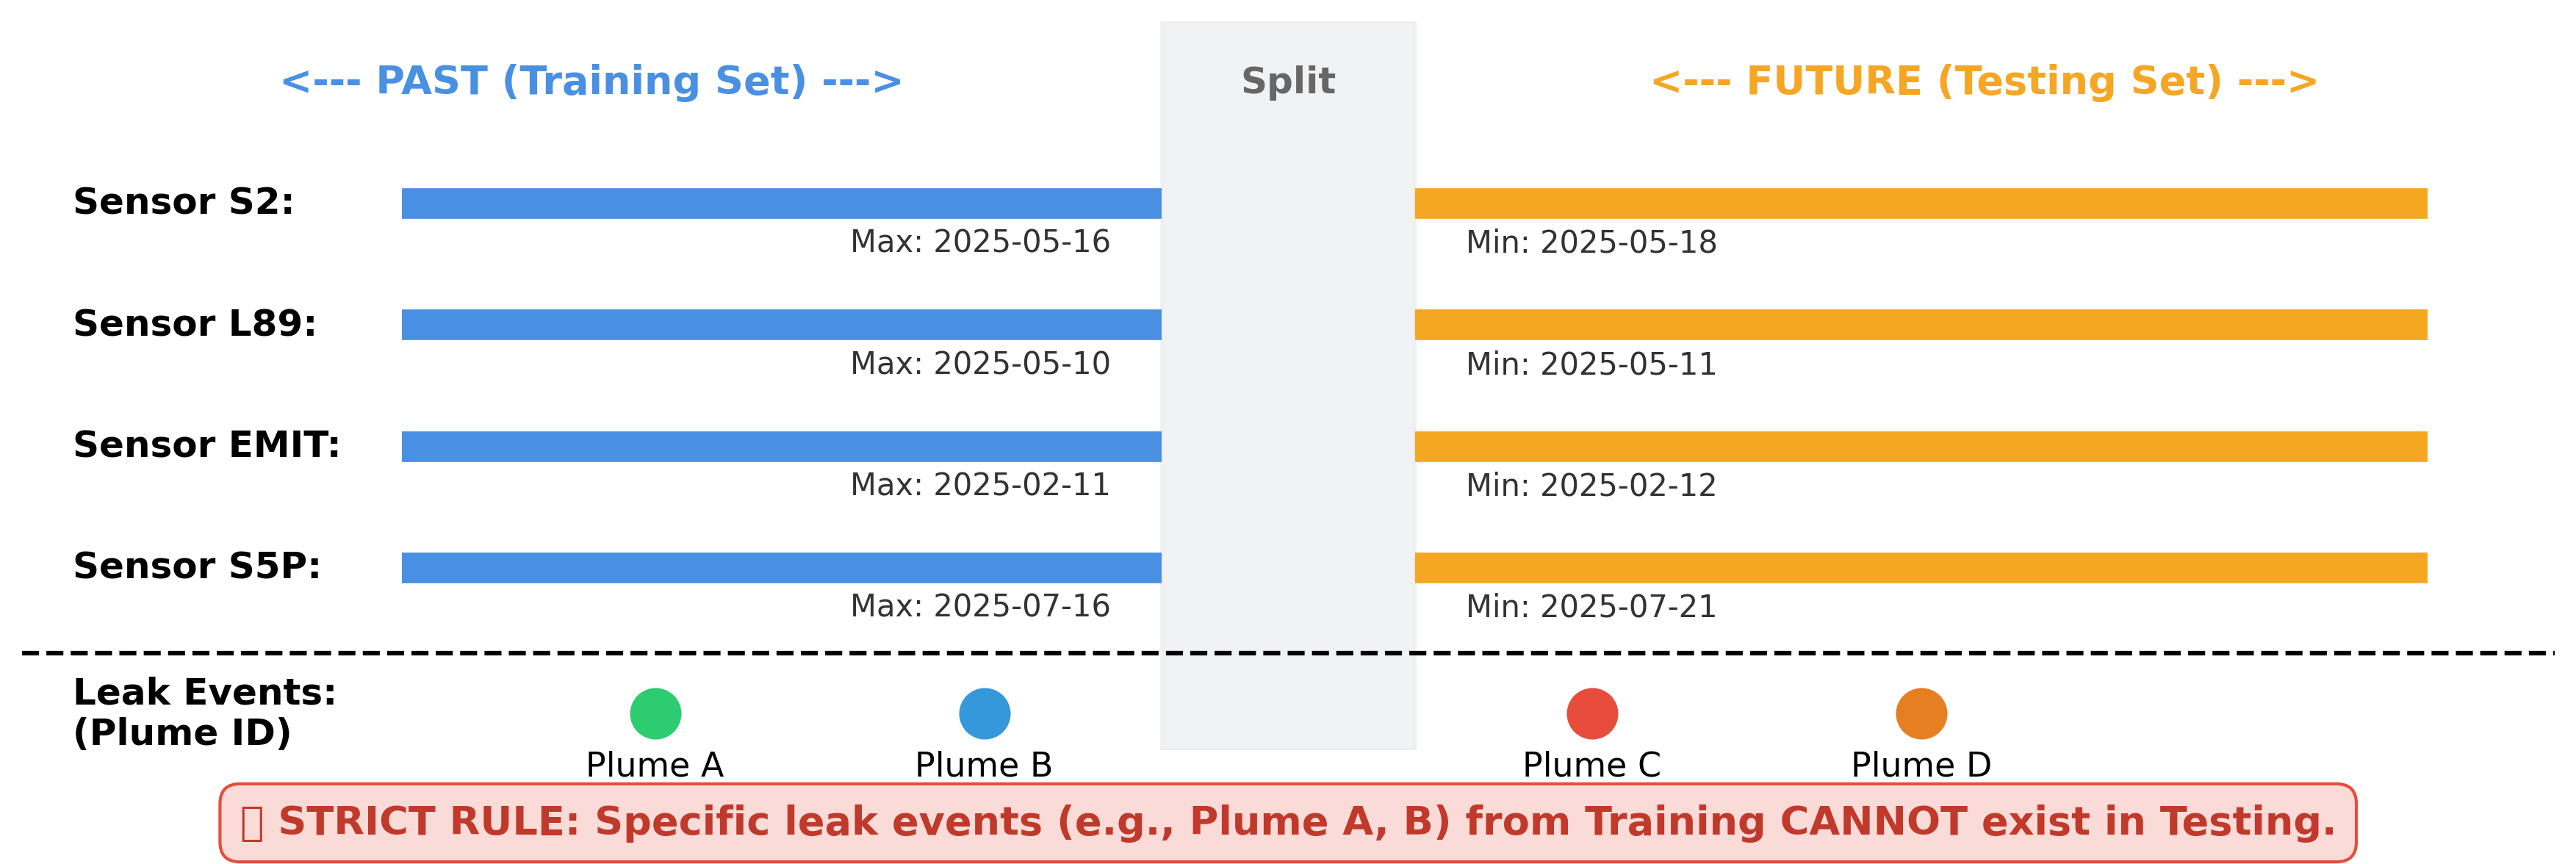

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. 设置更大的画布以容纳 4 个传感器
fig, ax = plt.subplots(figsize=(10, 4), dpi=300)
ax.set_xlim(0, 100)
ax.set_ylim(0, 6) # 增加 Y 轴空间

# 颜色定义
color_train = '#4a90e2'  # 训练集蓝色
color_test = '#f5a623'   # 测试集橙色
color_buffer = '#e8eaed' # Buffer区灰色
text_color = '#333333'

# 2. 画中心对齐的 Buffer (Gap) 区域
ax.axvspan(45, 55, color=color_buffer, alpha=0.6, zorder=0)
ax.text(50, 5.5, 'Split', ha='center', va='center', 
        fontsize=12, fontweight='bold', color='#666666')

# 3. 顶部区域标签
ax.text(22.5, 5.5, '<--- PAST (Training Set) --->', ha='center', va='center', 
        fontsize=13, fontweight='bold', color=color_train)
ax.text(77.5, 5.5, '<--- FUTURE (Testing Set) --->', ha='center', va='center', 
        fontsize=13, fontweight='bold', color=color_test)

# --- 定义画时间线的辅助函数 ---
def draw_timeline(y_pos, name, train_date, test_date):
    # Sensor Name
    ax.text(2, y_pos, name, ha='left', va='center', fontsize=12, fontweight='bold')
    
    # Train Line & Text
    ax.plot([15, 45], [y_pos, y_pos], color=color_train, linewidth=10, solid_capstyle='butt')
    ax.text(43, y_pos - 0.2, f'Max: {train_date}', ha='right', va='top', fontsize=10, color=text_color)
    
    # Test Line & Text
    ax.plot([55, 95], [y_pos, y_pos], color=color_test, linewidth=10, solid_capstyle='butt')
    ax.text(57, y_pos - 0.2, f'Min: {test_date}', ha='left', va='top', fontsize=10, color=text_color)

# 4. 依次画出 4 个传感器的时间线 (基于你提供的真实时间戳)
draw_timeline(4.5, 'Sensor S2:',   '2025-05-16', '2025-05-18')
draw_timeline(3.5, 'Sensor L89:',  '2025-05-10', '2025-05-11')
draw_timeline(2.5, 'Sensor EMIT:', '2025-02-11', '2025-02-12')
draw_timeline(1.5, 'Sensor S5P:',  '2025-07-16', '2025-07-21')

# 5. 画分割线
ax.plot([0, 100], [0.8, 0.8], color='black', linewidth=1.5, linestyle='--')

# 6. 画 Leak Events (泄漏事件物理隔离示意)
ax.text(2, 0.3, 'Leak Events:\n(Plume ID)', ha='left', va='center', fontsize=12, fontweight='bold')

# Train Set Plumes
ax.scatter(25, 0.3, s=250, color='#2ecc71', zorder=5) 
ax.text(25, 0, 'Plume A\n(Learned)', ha='center', va='top', fontsize=11)

ax.scatter(38, 0.3, s=250, color='#3498db', zorder=5) 
ax.text(38, 0, 'Plume B\n(Learned)', ha='center', va='top', fontsize=11)

# Test Set Plumes
ax.scatter(62, 0.3, s=250, color='#e74c3c', zorder=5) 
ax.text(62, 0, 'Plume C\n(UNSEEN)', ha='center', va='top', fontsize=11)

ax.scatter(75, 0.3, s=250, color='#e67e22', zorder=5) 
ax.text(75, 0, 'Plume D\n(UNSEEN)', ha='center', va='top', fontsize=11)

# 7. 底部严格规则声明
rule_text = "❌ STRICT RULE: Specific leak events (e.g., Plume A, B) from Training CANNOT exist in Testing."
ax.text(50, -0.6, rule_text, ha='center', va='center', fontsize=13, fontweight='bold', color='#c0392b',
        bbox=dict(facecolor='#fadbd8', edgecolor='#e74c3c', boxstyle='round,pad=0.5'))

# 8. 清理坐标轴并保存
ax.axis('off') 
plt.tight_layout()

plt.savefig('full_4sensors_temporal_split.png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()